# Part 4: Global Automobile Sales Analysis
### Part 4 of the [Automobile Sales Analysis](../README.md) Series

## 1. Introduction

Parts 1 and 2 of this series established that U.S. automobile sales are strongly correlated with the unemployment rate (r = -0.689) and consumer sentiment (r = +0.598), and that Random Forest - the best performing model from Part 2 - achieves mean CV $R^2$ of 0.436 using lagged sales values as the dominant feature. Part 3 extended the analysis to nine U.S. metropolitan areas and found that transit tier is a statistically significant structural determinant of per-capita vehicle registrations, explaining an additional 20% of variance beyond what economic conditions alone account for.

Part 4 takes the analysis to an international scale, examining new passenger car registrations across 14 countries grouped by vehicle ownership culture and transit availability. The central question is whether the relationship between economic conditions and auto sales differs systematically across markets - specifically, whether economic conditions play a larger role in markets where car purchase is more discretionary (strong transit alternatives available) versus markets where cars are a primary necessity.

The analysis uses annual passenger car registration data from the OECD short-term economic indicators database alongside GDP per capita, population, and urbanization data from the World Bank API.

### Country Groups

Countries are grouped by vehicle ownership culture and transit availability rather than geography, directly extending the transit tier framework from Part 3 to an international context.

| Group | Label | Countries |
|-------|-------|-----------|
| 1 | High Ownership / Limited Transit | United States, Canada, Australia |
| 2 | High Ownership / Strong Transit | Germany, France, United Kingdom, Italy, Japan, South Korea, Spain, Poland |
| 3 | Rising Ownership / Unequal Access | Brazil, Turkey, Chile |

### Business Questions

1. Do country groups differ significantly in per-capita new car registration rates?
2. Are some groups more sensitive to recessions than others?
3. Do economic conditions (GDP per capita, urbanization) explain registration differences across groups, or does group membership have an independent effect?
4. Does the momentum-dominated Random Forest pattern from Parts 2 and 3 hold internationally, or do economic indicators gain predictive power in specific market types?

> **Data note:** The OECD TOCAPA indicator covers new passenger car registrations only. Trucks, SUVs, and vans represent big portion of new vehicle sales especially in Group 1 (USA, Canada, Australia) but much smaller share in Group 2 and Group 3 markets. This creates systematic undercount Group 1 market activity that affects all registration-level comparisons across groups. Used vehicle purchases are also excluded for all countries which also creates systemic undercount for Group 3 since new registrations capture only the wealthier segment of the market. Group 2 is represented by the data the best; passenger cars dominate new sales and new car market is accessible to a broader population share.

## 2. Data Collection and Wrangling

### 2.1 Required Libraries

| Library | Purpose |
|---------|---------|
| `pandas`, `numpy` | Data manipulation and numerical computing |
| `matplotlib`, `seaborn` | Static visualizations |
| `wbgapi` | World Bank API for GDP per capita, population, and urbanization |
| `requests` | OECD SDMX REST API for passenger car registration data |
| `sqlite3` | Reading from and writing to `auto_sales_global.sqlite` |
| `sklearn` | Random Forest modeling and evaluation metrics |
| `scipy` | Kruskal-Wallis and Mann-Whitney U hypothesis tests |
| `statsmodels` | OLS regression |
| `dash`, `plotly` | Interactive dashboard |
| `warnings` | Suppress non-critical warnings |

> **API Keys:** No API keys are required for this notebook. The World Bank API (`wbgapi`) and the OECD SDMX REST API are both publicly accessible without authentication.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import json

import plotly
import dash

# Modeling - Part 1 & 2 baseline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from io import BytesIO
from io import StringIO
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import plotly.express as px


import requests
import folium
import wbgapi as wb

### 2.2 Configuration

Constants, country definitions, group assignments, and color mappings used throughout the notebook are defined here. All subsequent sections reference this configuration. `START_YEAR` and `END_YEAR` define the analysis window.

In [2]:
COUNTRIES = {
    # Group 1 - High Ownership, Limited Transit
    'United States':  {'group': 1, 'group_label': 'High Ownership / Limited Transit',  'iso3': 'USA', 'data_source': 'oecd', 'lat': 37.09,  'lon': -95.71},
    'Canada':         {'group': 1, 'group_label': 'High Ownership / Limited Transit',  'iso3': 'CAN', 'data_source': 'oecd', 'lat': 56.13,  'lon': -106.35},
    'Australia':      {'group': 1, 'group_label': 'High Ownership / Limited Transit',  'iso3': 'AUS', 'data_source': 'oecd', 'lat': -25.27, 'lon': 133.78},

    # Group 2 - High Ownership, Strong Transit
    'Germany':        {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'DEU', 'data_source': 'oecd', 'lat': 51.17,  'lon': 10.45},
    'France':         {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'FRA', 'data_source': 'oecd', 'lat': 46.23,  'lon': 2.21},
    'United Kingdom': {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'GBR', 'data_source': 'oecd', 'lat': 55.38,  'lon': -3.44},
    'Italy':          {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'ITA', 'data_source': 'oecd', 'lat': 41.87,  'lon': 12.57},
    'Japan':          {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'JPN', 'data_source': 'oecd', 'lat': 36.20,  'lon': 138.25},
    'South Korea':    {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'KOR', 'data_source': 'oecd', 'lat': 35.91,  'lon': 127.77},
    'Spain':          {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'ESP', 'data_source': 'oecd', 'lat': 40.46,  'lon': -3.75},
    'Poland':         {'group': 2, 'group_label': 'High Ownership / Strong Transit',   'iso3': 'POL', 'data_source': 'oecd', 'lat': 51.92,  'lon': 19.15},

    # Group 3 - Rising Ownership, Unequal Access
    'Brazil':         {'group': 3, 'group_label': 'Rising Ownership / Unequal Access', 'iso3': 'BRA', 'data_source': 'oecd', 'lat': -14.24, 'lon': -51.93},
    'Turkey':         {'group': 3, 'group_label': 'Rising Ownership / Unequal Access', 'iso3': 'TUR', 'data_source': 'oecd', 'lat': 38.96,  'lon': 35.24},
    'Chile':          {'group': 3, 'group_label': 'Rising Ownership / Unequal Access', 'iso3': 'CHL', 'data_source': 'oecd', 'lat': -35.68, 'lon': -71.54},
    }

START_YEAR = 2005
END_YEAR   = 2023

### 2.3 World Bank Economic Indicators

GDP per capita (PPP, constant 2017 USD), total population, and urbanization rate are retrieved from the World Bank API using the `wbgapi` library. PPP-adjusted GDP is used rather than nominal GDP to account for cost of living differences across countries, making cross-country comparisons more meaningful. All three indicators are available for all 14 countries with zero missing values across the 2005-2023 window.

In [3]:
iso3_codes = [info['iso3'] for info in COUNTRIES.values()]

wb_data = {}

for indicator_name, indicator_code in {
    'gdp_per_capita': 'NY.GDP.PCAP.PP.KD',
    'population':     'SP.POP.TOTL',
    'urbanization':   'SP.URB.TOTL.IN.ZS',
}.items():
    try:
        df = wb.data.DataFrame(
            indicator_code,
            economy=iso3_codes,
            time=range(START_YEAR, END_YEAR + 1),
            numericTimeKeys=True,
            labels=False
        ).T
        df.index.name = 'year'
        df.index = df.index.astype(int)
        wb_data[indicator_name] = df
        print(f"[OK]     {indicator_name:<20} {df.shape[0]} years x {df.shape[1]} countries")
    except Exception as e:
        print(f"[FAILED] {indicator_name:<20} ERROR: {e}")

assert len(wb_data) == 3, f"Expected 3 indicators, got {len(wb_data)}"
print(f"\nIndicators retrieved: {len(wb_data)}/3")
for name, df in wb_data.items():
    missing_pct = df.isnull().mean().mean() * 100
    print(f"  {name:<20} missing: {missing_pct:.1f}%")

[OK]     gdp_per_capita       19 years x 14 countries
[OK]     population           19 years x 14 countries
[OK]     urbanization         19 years x 14 countries

Indicators retrieved: 3/3
  gdp_per_capita       missing: 0.0%
  population           missing: 0.0%
  urbanization         missing: 0.0%


### 2.4 OECD Passenger Car Registrations

New passenger car registration data is retrieved from the OECD SDMX REST API using the INDSERV dataset (short-term industrial service statistics). Monthly data is pulled and aggregated to annual frequency by summing all 12 monthly observations within each calendar year. Only non-seasonally adjusted (`ADJUSTMENT=N`) and absolute count (`UNIT_MEASURE=VEH`) series are retained to avoid duplicates and ensure cross-country comparability.

Two countries in the OECD dataset - Colombia and India - report registrations as an index (base year 2015=100) rather than absolute vehicle counts, making cross-country level comparison impossible. They are excluded from the analysis.

> **Coverage note:** Mexico was unavailable in the OECD INDSERV dataset for the passenger car registrations measure and is excluded. Countries with index-only data (Colombia, India) are also excluded, leaving 14 countries with comparable absolute registration counts.

In [4]:
oecd_countries = '+'.join(
    info['iso3'] for info in COUNTRIES.values()
    if info['data_source'] == 'oecd'
)

OECD_URL = (
    'https://sdmx.oecd.org/public/rest/data/'
    'OECD.SDD.STES,DSD_STES@DF_INDSERV,4.3/'
    f'{oecd_countries}'
    '.M.TOCAPA......?'
    'startPeriod=2005-01&endPeriod=2023-12'
    '&dimensionAtObservation=AllDimensions&format=csvfile'
)

r = requests.get(OECD_URL, timeout=60)
r.raise_for_status()

df_oecd_monthly = pd.read_csv(StringIO(r.text))

df_oecd_monthly = df_oecd_monthly[
    (df_oecd_monthly['ADJUSTMENT'] == 'N') &
    (df_oecd_monthly['UNIT_MEASURE'] == 'VEH')
].copy()

df_oecd_monthly['year'] = df_oecd_monthly['TIME_PERIOD'].str[:4].astype(int)

df_registrations = (
    df_oecd_monthly
    .groupby(['REF_AREA', 'year'])['OBS_VALUE']
    .sum()
    .reset_index()
    .rename(columns={'REF_AREA': 'iso3', 'OBS_VALUE': 'registrations'})
)

df_registrations_wide = df_registrations.pivot(
    index='year', columns='iso3', values='registrations'
)
df_registrations_wide.index.name = 'year'

assert df_registrations_wide.shape[0] == 19, \
    f"Expected 19 years, got {df_registrations_wide.shape[0]}"
assert df_registrations_wide.shape[1] == 14, \
    f"Expected 14 countries, got {df_registrations_wide.shape[1]}"

missing_pct = df_registrations_wide.isnull().mean().mean() * 100
print(f"[OK] OECD passenger car registrations (VEH only)")
print(f"     {df_registrations_wide.shape[0]} years x {df_registrations_wide.shape[1]} countries")
print(f"     Missing: {missing_pct:.1f}%")
print(f"     Countries: {sorted(df_registrations_wide.columns.tolist())}")

[OK] OECD passenger car registrations (VEH only)
     19 years x 14 countries
     Missing: 0.0%
     Countries: ['AUS', 'BRA', 'CAN', 'CHL', 'DEU', 'ESP', 'FRA', 'GBR', 'ITA', 'JPN', 'KOR', 'POL', 'TUR', 'USA']


### 2.5 Data Storage

All retrieved datasets are written to `auto_sales_global.sqlite` - a separate database from the `auto_sales.sqlite` used in Parts 1 through 3. This keeps the global analysis data isolated from the U.S. national and regional data while maintaining the series convention of using SQLite for all data persistence.

Six tables are created: `wb_gdp_per_capita`, `wb_population`, `wb_urbanization`, `oecd_registrations`, `who_death_rate`, and `country_metadata`.

In [5]:
with sqlite3.connect('auto_sales_global.sqlite') as conn:

    # World Bank economic indicators - save each in long format
    for indicator_name, df in wb_data.items():
        df_long = df.reset_index().melt(
            id_vars='year',
            var_name='iso3',
            value_name=indicator_name
        )
        df_long.to_sql(
            f'wb_{indicator_name}', conn,
            if_exists='replace', index=False
        )

    # OECD passenger car registrations - long format
    df_registrations.to_sql(
        'oecd_registrations', conn,
        if_exists='replace', index=False
    )

   # Country metadata
    df_meta = pd.DataFrame([
        {
            'country':     country,
            'iso3':        info['iso3'],
            'group':       info['group'],
            'group_label': info['group_label'],
            'data_source': info['data_source'],
            'lat':         info['lat'],
            'lon':         info['lon'],
        }
        for country, info in COUNTRIES.items()
    ])
    df_meta.to_sql(
        'country_metadata', conn,
        if_exists='replace', index=False
    )

print("Tables written to auto_sales_global.sqlite:")
print("  wb_gdp_per_capita       (World Bank GDP per capita PPP, annual)")
print("  wb_population           (World Bank population, annual)")
print("  wb_urbanization         (World Bank urbanization rate, annual)")
print("  oecd_registrations      (OECD passenger car registrations, annual)")
print("  who_death_rate          (WHO road traffic death rate, 2021)")
print("  country_metadata        (group classifications, coordinates)")

Tables written to auto_sales_global.sqlite:
  wb_gdp_per_capita       (World Bank GDP per capita PPP, annual)
  wb_population           (World Bank population, annual)
  wb_urbanization         (World Bank urbanization rate, annual)
  oecd_registrations      (OECD passenger car registrations, annual)
  who_death_rate          (WHO road traffic death rate, 2021)
  country_metadata        (group classifications, coordinates)


## 3. Group Classification and Validation

### 3.1 Group Classification Summary

The 2019 pre-COVID baseline is used to characterize each country across four dimensions: GDP per capita, urbanization rate, new registrations per 1,000 people, and WHO 2021 road traffic death rate. Road traffic death rate serves as a cross-validation indicator - higher vehicle prevalence countries generally have higher death rates - allowing the group assignments to be checked against an independent data source.

In [6]:
from IPython.display import display, Markdown

with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_meta_s3 = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )
    df_gdp = pd.read_sql_query(
        "SELECT * FROM wb_gdp_per_capita", conn
    ).pivot(index='year', columns='iso3', values='gdp_per_capita')
    df_urb = pd.read_sql_query(
        "SELECT * FROM wb_urbanization", conn
    ).pivot(index='year', columns='iso3', values='urbanization')
    df_who_s3 = pd.read_sql_query(
        "SELECT * FROM who_death_rate", conn
    )
    df_reg_s3 = pd.read_sql_query(
        "SELECT * FROM oecd_registrations", conn
    )

# Filter to OECD countries only (data_source == 'oecd')
oecd_iso3 = df_meta_s3[df_meta_s3['data_source'] == 'oecd']['iso3'].tolist()

# 2019 pre-COVID snapshot for group characterization
gdp_2019 = df_gdp.loc[2019, oecd_iso3]
urb_2019 = df_urb.loc[2019, oecd_iso3]

# Annual registrations per capita (2019)
pop_2019 = pd.read_sql_query(
    "SELECT * FROM wb_population WHERE year = 2019",
    sqlite3.connect('auto_sales_global.sqlite')
).pivot(index='year', columns='iso3', values='population').loc[2019]

reg_2019 = df_reg_s3[df_reg_s3['year'] == 2019].set_index('iso3')['registrations']
reg_pc_2019 = (reg_2019 / pop_2019) * 1000  # per 1000 people

# WHO death rate
who_dict = df_who_s3.set_index('iso3')['death_rate_2021'].to_dict()

# Build summary table
summary_records = []
for _, row in df_meta_s3[df_meta_s3['data_source'] == 'oecd'].iterrows():
    iso3   = row['iso3']
    country = row['country']
    group  = row['group']
    summary_records.append({
        'Country':          country,
        'Group':            group,
        'Group Label':      row['group_label'],
        'GDP/capita 2019':  round(gdp_2019.get(iso3, float('nan')), 0),
        'Urban % 2019':     round(urb_2019.get(iso3, float('nan')), 1),
        'Reg/1000 2019':    round(reg_pc_2019.get(iso3, float('nan')), 2),
        'Death Rate 2021':  who_dict.get(iso3, float('nan')),
    })

df_summary_s3 = pd.DataFrame(summary_records).sort_values(['Group', 'Country'])

display(Markdown("**Group Classification Summary - 2019 Pre-COVID Baseline**"))
display(df_summary_s3.set_index('Country'))

**Group Classification Summary - 2019 Pre-COVID Baseline**

,Group,Group Label,GDP/capita 2019,Urban % 2019,Reg/1000 2019,Death Rate 2021
Country,,,,,,
Australia,1,High Ownership / Limited Transit,58049.0,87.3,12.53,4.5
Canada,1,High Ownership / Limited Transit,57584.0,81.7,13.21,4.7
United States,1,High Ownership / Limited Transit,69113.0,80.1,14.29,14.2
France,2,High Ownership / Strong Transit,53449.0,78.7,33.51,4.7
Germany,2,High Ownership / Strong Transit,62849.0,81.3,43.41,3.3
Italy,2,High Ownership / Strong Transit,49691.0,69.5,32.00,5.0
Japan,2,High Ownership / Strong Transit,44731.0,91.7,22.28,2.7
Poland,2,High Ownership / Strong Transit,38182.0,60.0,14.63,6.5
South Korea,2,High Ownership / Strong Transit,49791.0,81.3,29.16,6.9


### 3.2 Validation Chart

Three scatter plots show group separation across GDP per capita, registrations per 1,000 people, and road traffic death rates. Clean separation across all three dimensions validates that the group assignments reflect genuinely distinct market types rather than arbitrary geographic clusters.

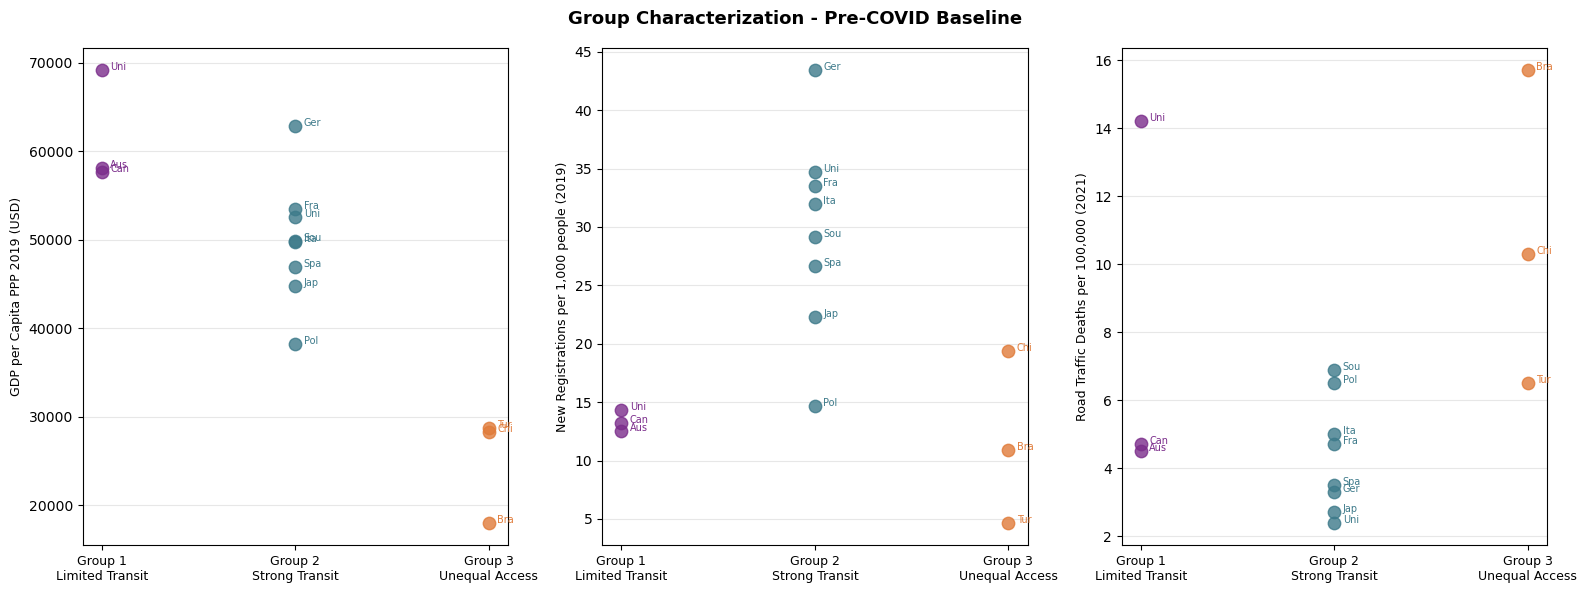

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

GROUP_COLORS = {1: '#7B2D8B', 2: '#3D7A8A', 3: '#E07B39'}

metrics = [
    ('GDP/capita 2019',  'GDP per Capita PPP 2019 (USD)'),
    ('Reg/1000 2019',    'New Registrations per 1,000 people (2019)'),
    ('Death Rate 2021',  'Road Traffic Deaths per 100,000 (2021)'),
]

for ax, (metric, label) in zip(axes, metrics):
    for group in [1, 2, 3]:
        subset = df_summary_s3[df_summary_s3['Group'] == group]
        color  = GROUP_COLORS[group]
        ax.scatter(
            [group] * len(subset),
            subset[metric],
            color=color, s=80, alpha=0.8, zorder=3
        )
        # Add country labels
        for _, r in subset.iterrows():
            ax.annotate(
                r['Country'][:3],
                (group, r[metric]),
                textcoords='offset points',
                xytext=(6, 0),
                fontsize=7, color=color
            )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([
        'Group 1\nLimited Transit',
        'Group 2\nStrong Transit',
        'Group 3\nUnequal Access'
    ], fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Group Characterization - Pre-COVID Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Group Classification - Findings

**GDP per capita** separates groups cleanly - Group 1 ($57-69k), Group 2 ($38-63k with Poland as the lower outlier), Group 3 ($18-29k). The income gradient is consistent with the ownership and transit profiles assigned to each group.

**Registrations per 1,000 people** produces a counterintuitive result: Group 2 (Strong Transit) has the highest median registrations, not Group 1 (Limited Transit). This reflects the primary data limitation of the analysis - the OECD TOCAPA measure covers passenger cars only, excluding the trucks and SUVs that dominate Group 1 markets. The indicator systematically undercounts Group 1 market activity and this caveat applies throughout all subsequent analysis.

**Road traffic death rates** show Group 2 as the safest (2.4-6.9 per 100,000), Group 3 the highest (6.5-15.7), and Group 1 with the United States as a notable outlier at 14.2 - well above Canada (4.7) and Australia (4.5) despite belonging to the same group. Turkey at 4.68 registrations per 1,000 people sits closer to Group 1 levels than Group 3 in that dimension.

> **Note on Turkey:** Turkey's registration figure is depressed relative to its GDP level, likely reflecting the impact of currency volatility on new car affordability. The 2020 COVID spike visible in the recession chart reflects a currency-driven rush to purchase hard assets rather than economic recovery.

## 4. EDA - Regional Patterns

### 4.1 Data Preparation

All data for Section 4 is loaded from `auto_sales_global.sqlite`. Per-capita registration rates are computed by dividing annual registration counts by national population (converted from thousands). The resulting long-format DataFrame maps each country to its group and serves as the basis for all EDA charts in this section.

In [8]:
# 4.1 Data Preparation

from IPython.display import display, Markdown

with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_reg_eda = pd.read_sql_query(
        "SELECT * FROM oecd_registrations", conn
    )
    df_pop_eda = pd.read_sql_query(
        "SELECT * FROM wb_population", conn
    ).pivot(index='year', columns='iso3', values='population')
    df_gdp_eda = pd.read_sql_query(
        "SELECT * FROM wb_gdp_per_capita", conn
    ).pivot(index='year', columns='iso3', values='gdp_per_capita')
    df_urb_eda = pd.read_sql_query(
        "SELECT * FROM wb_urbanization", conn
    ).pivot(index='year', columns='iso3', values='urbanization')
    df_meta_eda = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )

# Filter metadata to OECD VEH countries only
oecd_veh_iso3 = sorted(df_registrations_wide.columns.tolist())
df_meta_oecd = df_meta_eda[df_meta_eda['iso3'].isin(oecd_veh_iso3)].copy()

# Per capita registrations - population in thousands so multiply by 1000
df_pop_full = df_pop_eda * 1000

# Build long format plotting DataFrame
plot_records = []
for _, meta_row in df_meta_oecd.iterrows():
    iso3    = meta_row['iso3']
    country = meta_row['country']
    group   = meta_row['group']
    group_label = meta_row['group_label']

    reg_series = df_reg_eda[df_reg_eda['iso3'] == iso3].set_index('year')['registrations']
    pop_series = df_pop_full[iso3] if iso3 in df_pop_full.columns else None

    for year in reg_series.index:
        reg = reg_series.loc[year]
        pop = pop_series.loc[year] if pop_series is not None and year in pop_series.index else np.nan
        plot_records.append({
            'year':        year,
            'iso3':        iso3,
            'country':     country,
            'group':       group,
            'group_label': group_label,
            'registrations': reg,
            'reg_pc':      (reg / pop) * 1000 if not np.isnan(pop) and pop > 0 else np.nan,
            'gdp_pc':      df_gdp_eda.loc[year, iso3] if iso3 in df_gdp_eda.columns and year in df_gdp_eda.index else np.nan,
            'urbanization': df_urb_eda.loc[year, iso3] if iso3 in df_urb_eda.columns and year in df_urb_eda.index else np.nan,
        })

df_plot_eda = pd.DataFrame(plot_records)

print(f"EDA dataset: {df_plot_eda.shape[0]} rows")
print(f"Countries: {df_plot_eda['country'].nunique()}")
print(f"Years: {df_plot_eda['year'].min()} - {df_plot_eda['year'].max()}")
print(f"Missing reg_pc: {df_plot_eda['reg_pc'].isnull().sum()}")

EDA dataset: 266 rows
Countries: 14
Years: 2005 - 2023
Missing reg_pc: 0


### 4.2 Registrations per Capita Over Time by Country (2005-2023)

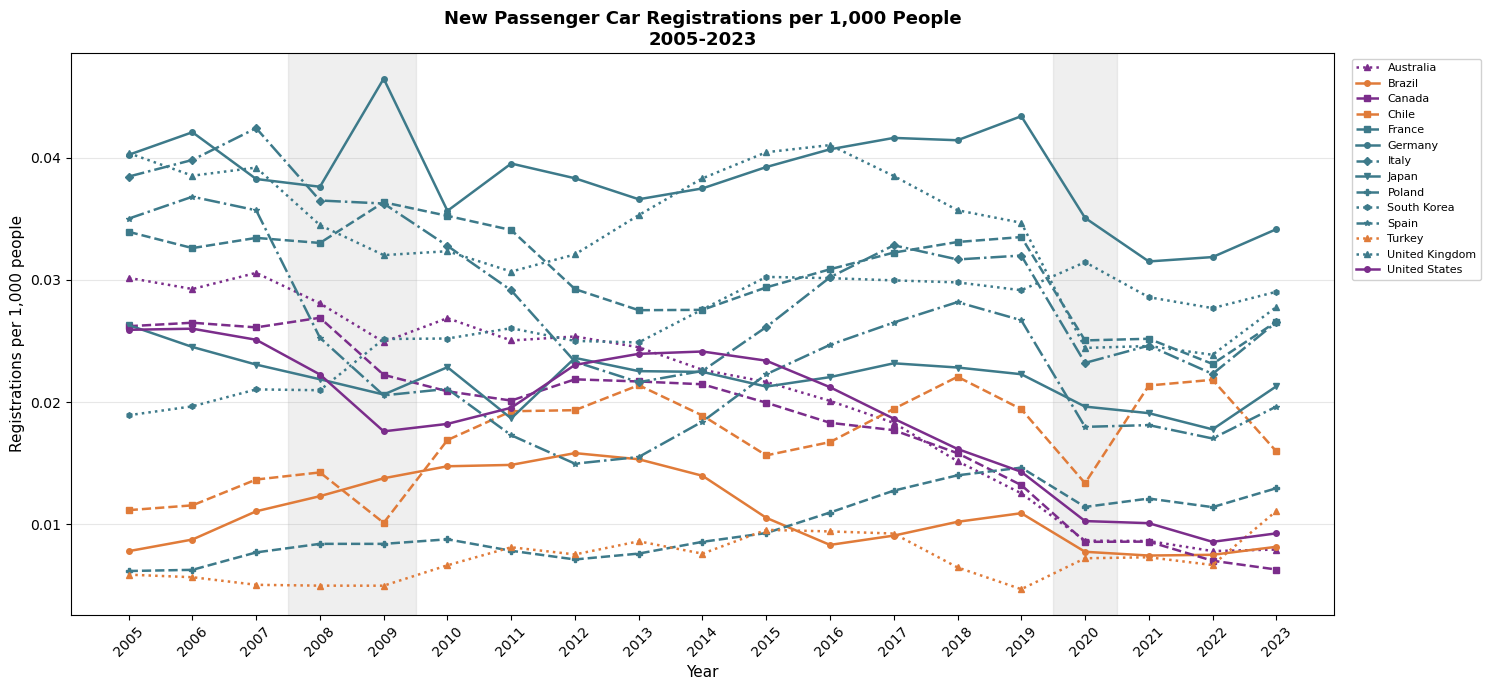

In [9]:
COUNTRY_STYLES = {
    'United States':  ('-',  'o'),
    'Canada':         ('--', 's'),
    'Australia':      (':',  '^'),
    'Germany':        ('-',  'o'),
    'France':         ('--', 's'),
    'United Kingdom': (':',  '^'),
    'Italy':          ('-.',  'D'),
    'Japan':          ('-',  'v'),
    'Poland':         ('--', 'P'),
    'South Korea':    (':',  'h'),
    'Spain':          ('-.',  '*'),
    'Brazil':         ('-',  'o'),
    'Chile':          ('--', 's'),
    'Turkey':         (':',  '^'),
}

RECESSION_BANDS = [(2008, 2009), (2020, 2020)]

fig, ax = plt.subplots(figsize=(15, 7))

for country, group_df in df_plot_eda.groupby('country'):
    group = group_df['group'].iloc[0]
    color = GROUP_COLORS[group]
    ls, marker = COUNTRY_STYLES.get(country, ('-', 'o'))
    ax.plot(
        group_df['year'], group_df['reg_pc'],
        color=color, linestyle=ls, linewidth=1.8,
        marker=marker, markersize=4, label=country
    )

for start, end in RECESSION_BANDS:
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.12, color='grey', zorder=0)

ax.set_title('New Passenger Car Registrations per 1,000 People\n2005-2023',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Registrations per 1,000 people', fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(2005, 2024))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Registration Distribution by Group

Box plots of annual per-capita registrations by group, restricted to the pre-COVID baseline period (2005-2019) to exclude pandemic-driven distortions.

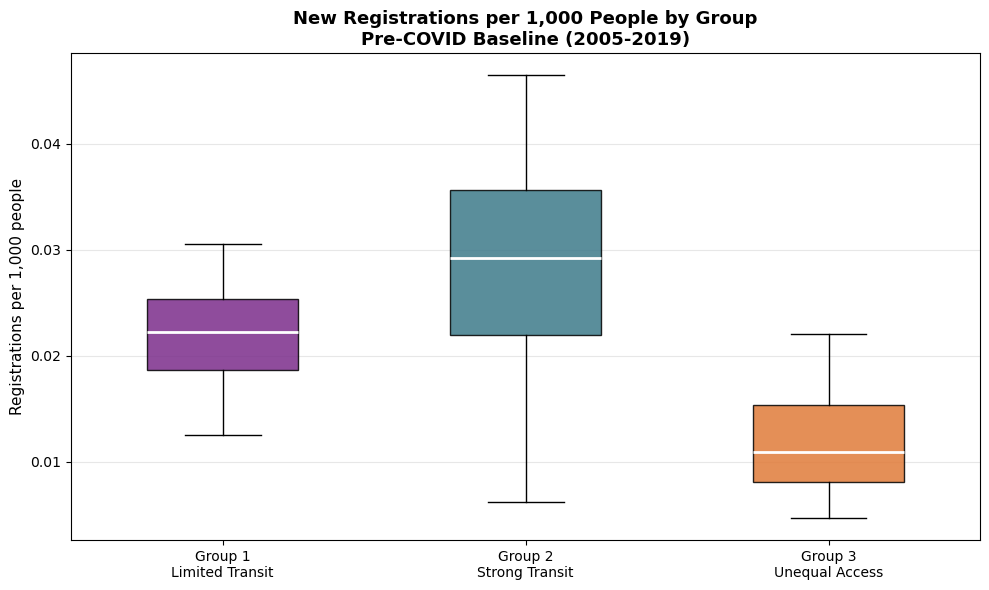

In [10]:
# Pre-COVID baseline 2005-2019

df_pre_covid = df_plot_eda[df_plot_eda['year'] <= 2019]

fig, ax = plt.subplots(figsize=(10, 6))

data_by_group = [
    df_pre_covid[df_pre_covid['group'] == g]['reg_pc'].dropna().values
    for g in [1, 2, 3]
]

bp = ax.boxplot(data_by_group, patch_artist=True, widths=0.5,
                medianprops={'color': 'white', 'linewidth': 2})

for patch, color in zip(bp['boxes'], [GROUP_COLORS[g] for g in [1, 2, 3]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([
    'Group 1\nLimited Transit',
    'Group 2\nStrong Transit',
    'Group 3\nUnequal Access'
], fontsize=10)
ax.set_title('New Registrations per 1,000 People by Group\nPre-COVID Baseline (2005-2019)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Registrations per 1,000 people', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Recession Sensitivity: Peak-to-Trough Drop by Group

Percentage change in per-capita registrations between the pre-recession peak year and the trough year, measured separately for the 2008-2009 financial crisis (peak 2007, trough 2009) and the 2020 COVID recession (peak 2019, trough 2020).

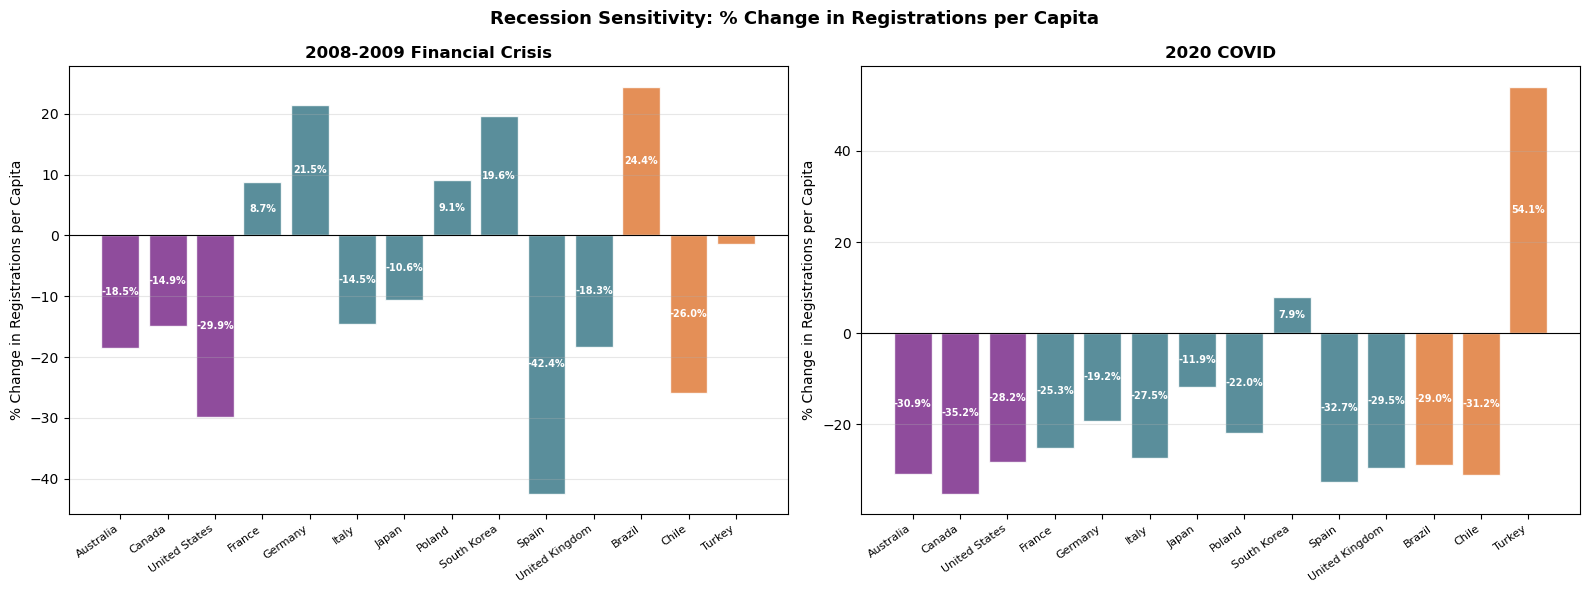

In [11]:
recessions = {
    '2008-2009 Financial Crisis': (2007, 2009),
    '2020 COVID':                 (2019, 2020),
}

recession_records = []
for recession_name, (peak_yr, trough_yr) in recessions.items():
    for country, group_df in df_plot_eda.groupby('country'):
        group_df = group_df.set_index('year')
        if peak_yr in group_df.index and trough_yr in group_df.index:
            peak  = group_df.loc[peak_yr, 'reg_pc']
            trough = group_df.loc[trough_yr, 'reg_pc']
            if pd.notna(peak) and pd.notna(trough) and peak > 0:
                pct_change = ((trough - peak) / peak) * 100
                recession_records.append({
                    'recession':  recession_name,
                    'country':    country,
                    'group':      group_df['group'].iloc[0],
                    'pct_change': pct_change
                })

df_recession_eda = pd.DataFrame(recession_records)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, recession_name in zip(axes, recessions.keys()):
    subset = df_recession_eda[
        df_recession_eda['recession'] == recession_name
    ].sort_values('group')
    colors = [GROUP_COLORS[g] for g in subset['group']]
    bars = ax.bar(range(len(subset)), subset['pct_change'],
                  color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset['country'], rotation=35, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(recession_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('% Change in Registrations per Capita', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, subset['pct_change']):
        if abs(val) >= 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val / 2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

fig.suptitle('Recession Sensitivity: % Change in Registrations per Capita',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 GDP per Capita vs Registrations per Capita

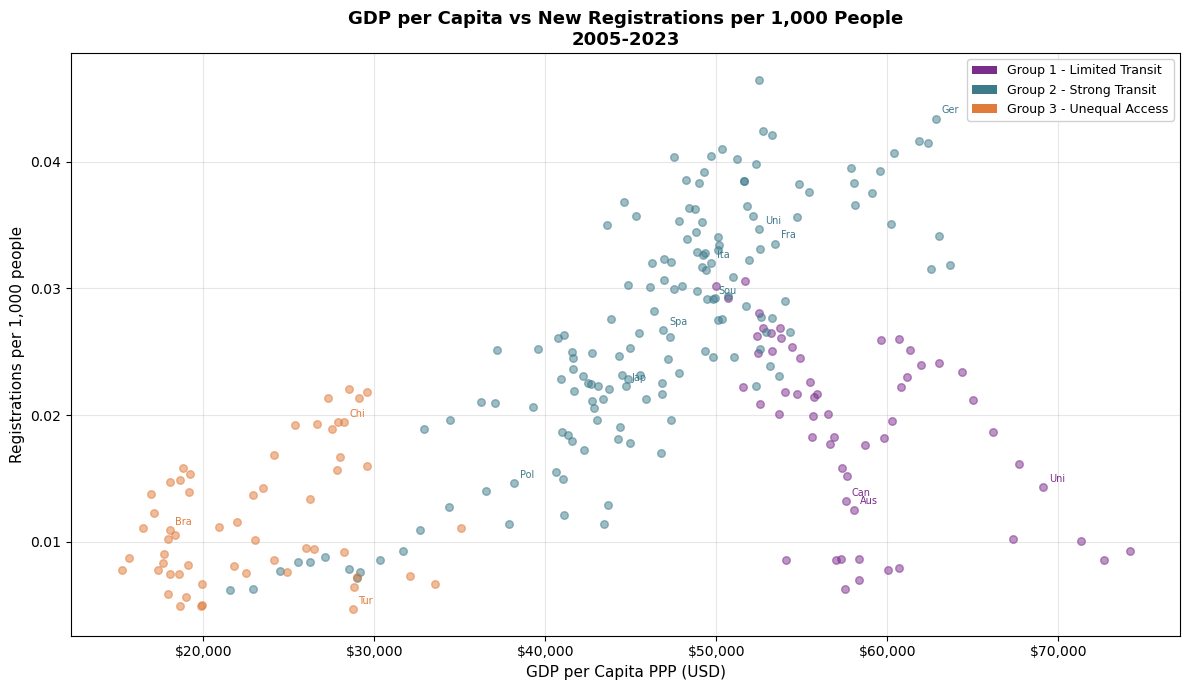

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

for country, group_df in df_plot_eda.groupby('country'):
    group = group_df['group'].iloc[0]
    color = GROUP_COLORS[group]
    ax.scatter(
        group_df['gdp_pc'], group_df['reg_pc'],
        color=color, alpha=0.5, s=30, zorder=3
    )

# Add country labels at 2019 position
for country, group_df in df_plot_eda[df_plot_eda['year'] == 2019].groupby('country'):
    group = group_df['group'].iloc[0]
    color = GROUP_COLORS[group]
    ax.annotate(
        country[:3],
        (group_df['gdp_pc'].iloc[0], group_df['reg_pc'].iloc[0]),
        fontsize=7, color=color,
        xytext=(4, 4), textcoords='offset points'
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=GROUP_COLORS[1], label='Group 1 - Limited Transit'),
    Patch(facecolor=GROUP_COLORS[2], label='Group 2 - Strong Transit'),
    Patch(facecolor=GROUP_COLORS[3], label='Group 3 - Unequal Access'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9)

ax.set_title('GDP per Capita vs New Registrations per 1,000 People\n2005-2023',
             fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita PPP (USD)', fontsize=11)
ax.set_ylabel('Registrations per 1,000 people', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 EDA - Findings

The time series chart reveals clear group separation - Group 2 countries (teal) cluster in the upper half of the chart, Group 3 (orange) in the lower half, and Group 1 (purple) in the middle. Germany is the standout outlier at the top, reflecting both its large domestic auto industry and strong car culture alongside excellent transit. Turkey and Brazil anchor the bottom of Group 3.

The box plot confirms the counterintuitive finding from the group classification: Group 2 (Strong Transit) has both a higher median and a wider distribution than Group 1 (Limited Transit). The TOCAPA passenger car limitation is the most likely explanation - Group 1 markets are substantially undercounted.

The recession sensitivity chart shows heterogeneous responses within each group that challenge a simple group-level narrative. During 2008-2009, Spain (-42.4%) and the United Kingdom (-18.3%) were hit hardest within Group 2, while Germany (+21.5%) and Poland (+19.6%) grew - Germany benefiting from a government scrappage scheme and Poland from EU accession-driven growth. Chile (+24.4%) grew within Group 3, insulated from the global financial system. During COVID, Turkey (+54.1%) is a dramatic outlier driven by currency depreciation - a rush to convert lira savings into hard assets rather than genuine demand growth.

The GDP versus registrations scatter confirms strong positive association for Groups 2 and 3, with Group 1 showing a negative within-group relationship - higher GDP years are associated with fewer passenger car registrations within the USA, Canada, and Australia combined. This is discussed further in Section 6.

## 5. Hypothesis Testing

The EDA identified apparent differences in registration levels across groups. This section formalizes those observations as testable hypotheses and evaluates them using non-parametric tests appropriate for the sample size and distribution characteristics observed.

The primary hypothesis concerns per-capita vehicle registrations. Two secondary hypotheses examine whether group structure also predicts sensitivity to the 2008-2009 financial crisis and the 2020 COVID recession.

> **Choice of test:** Kruskal-Wallis is used instead of one-way ANOVA because the box plots in Section 4 revealed non-normal distributions and the effective sample size is small (14 countries). The Kruskal-Wallis test makes no normality assumption and is appropriate for ordinal group comparisons with small samples.

### 5.1 Hypothesis Testing Setup

All data is loaded from `auto_sales_global.sqlite`. The analysis uses the pre-COVID baseline period (2005-2019) to exclude pandemic-driven distortions. The repeated measures structure - 15 annual observations per country - inflates the effective sample size; the true independent sample size is 14 countries.

In [13]:
from scipy import stats
from IPython.display import display, Markdown

with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_reg_h = pd.read_sql_query(
        "SELECT * FROM oecd_registrations", conn
    )
    df_pop_h = pd.read_sql_query(
        "SELECT * FROM wb_population", conn
    ).pivot(index='year', columns='iso3', values='population')
    df_meta_h = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )

df_pop_h_full = df_pop_h * 1000
oecd_veh_iso3 = sorted(df_registrations_wide.columns.tolist())
df_meta_h = df_meta_h[df_meta_h['iso3'].isin(oecd_veh_iso3)].copy()

# Build per capita registrations wide format
df_reg_pc_h = df_reg_h.copy()
df_reg_pc_h['reg_pc'] = df_reg_h.apply(
    lambda row: (row['registrations'] / df_pop_h_full.loc[row['year'], row['iso3']]) * 1000
    if row['iso3'] in df_pop_h_full.columns and row['year'] in df_pop_h_full.index
    else np.nan,
    axis=1
)

# Pre-COVID baseline
df_test_h = df_reg_pc_h[
    (df_reg_pc_h['year'] >= 2005) &
    (df_reg_pc_h['year'] <= 2019)
].merge(df_meta_h[['iso3', 'group']], on='iso3')

group1 = df_test_h[df_test_h['group'] == 1]['reg_pc'].dropna().values
group2 = df_test_h[df_test_h['group'] == 2]['reg_pc'].dropna().values
group3 = df_test_h[df_test_h['group'] == 3]['reg_pc'].dropna().values

display(Markdown(f"""
**Hypothesis Testing Setup**

Pre-COVID baseline: 2005-2019

Sample sizes:
- Group 1 (Limited Transit): n={len(group1)}
- Group 2 (Strong Transit): n={len(group2)}
- Group 3 (Unequal Access): n={len(group3)}

Medians (registrations per 1,000 people):
- Group 1: {np.median(group1):.4f}
- Group 2: {np.median(group2):.4f}
- Group 3: {np.median(group3):.4f}
"""))


**Hypothesis Testing Setup**

Pre-COVID baseline: 2005-2019

Sample sizes:
- Group 1 (Limited Transit): n=45
- Group 2 (Strong Transit): n=120
- Group 3 (Unequal Access): n=45

Medians (registrations per 1,000 people):
- Group 1: 0.0222
- Group 2: 0.0292
- Group 3: 0.0109


### 5.2 Main Hypothesis: Do Groups Differ in Registration Rates?

**H0:** Per-capita registrations do not differ significantly across groups.

**H1:** Per-capita registrations differ significantly across groups - ownership culture and transit availability affect new car registration rates.

The Kruskal-Wallis test is applied to pre-COVID annual per-capita registrations across all three groups. Significance level: $\alpha$ = 0.05.

In [14]:
alpha = 0.05

stat, p_value = stats.kruskal(group1, group2, group3)

n_total = len(group1) + len(group2) + len(group3)
k = 3
eta_squared = (stat - k + 1) / (n_total - k)

decision = "REJECT H0" if p_value < alpha else "FAIL TO REJECT H0"
evidence = "Evidence that transit/ownership group affects per-capita registrations" \
           if p_value < alpha else \
           "Insufficient evidence that groups differ in per-capita registrations"

if eta_squared < 0.01:
    effect = "Negligible"
elif eta_squared < 0.06:
    effect = "Small"
elif eta_squared < 0.14:
    effect = "Medium"
else:
    effect = "Large"

display(Markdown(f"""
**MAIN HYPOTHESIS TEST**

**H0:** Per-capita registrations do not differ significantly across groups
**H1:** Per-capita registrations differ significantly across groups

**Kruskal-Wallis Test:**
Test statistic (H): {stat:.4f}
p-value: {p_value:.4f}
Effect size ($\\eta^2$): {eta_squared:.4f}

**Decision** ($\\alpha$ = {alpha}):
p = {p_value:.4f} -> {decision}
{evidence}

**Effect size:** $\\eta^2$ = {eta_squared:.4f} -> {effect} effect
"""))


**MAIN HYPOTHESIS TEST**

**H0:** Per-capita registrations do not differ significantly across groups
**H1:** Per-capita registrations differ significantly across groups

**Kruskal-Wallis Test:**
Test statistic (H): 82.1878
p-value: 0.0000
Effect size ($\eta^2$): 0.3874

**Decision** ($\alpha$ = 0.05):
p = 0.0000 -> REJECT H0
Evidence that transit/ownership group affects per-capita registrations

**Effect size:** $\eta^2$ = 0.3874 -> Large effect


### 5.3 Pairwise Mann-Whitney U Tests

Because the Kruskal-Wallis test is significant, pairwise comparisons are warranted to determine which specific group pairs drive the result. Mann-Whitney U tests are applied to all three pairs with Bonferroni correction for multiple comparisons. The adjusted significance threshold is $\alpha$ = 0.05 / 3 = 0.0167.

In [15]:
alpha_adj = alpha / 3

pairs = [
    ('Group 1', 'Group 2', group1, group2),
    ('Group 1', 'Group 3', group1, group3),
    ('Group 2', 'Group 3', group2, group3),
]

results_md = f"**PAIRWISE MANN-WHITNEY U TESTS**\n\nBonferroni-adjusted $\\alpha$ = {alpha_adj:.4f}\n\n"

for name_a, name_b, data_a, data_b in pairs:
    stat_mw, p_mw = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
    sig = "SIGNIFICANT" if p_mw < alpha_adj else "not significant"
    results_md += f"**{name_a} vs {name_b}:**\nU = {stat_mw:.1f}, p = {p_mw:.4f} -> {sig}\n\n"

display(Markdown(results_md))

**PAIRWISE MANN-WHITNEY U TESTS**

Bonferroni-adjusted $\alpha$ = 0.0167

**Group 1 vs Group 2:**
U = 1549.0, p = 0.0000 -> SIGNIFICANT

**Group 1 vs Group 3:**
U = 1886.0, p = 0.0000 -> SIGNIFICANT

**Group 2 vs Group 3:**
U = 4891.0, p = 0.0000 -> SIGNIFICANT



### 5.4 Secondary Hypothesis: Recession Sensitivity (2008-2009)

**H0:** The 2008-2009 financial crisis impacted per-capita registrations equally across groups.

**H1:** Recession impact differed significantly across groups.

The Kruskal-Wallis test is applied to the percentage change in per-capita registrations from 2007 (peak) to 2009 (trough) for each country.

In [16]:
rec_2008 = df_recession_eda[
    df_recession_eda['recession'] == '2008-2009 Financial Crisis'
].copy()

g1_rec = rec_2008[rec_2008['group'] == 1]['pct_change'].values
g2_rec = rec_2008[rec_2008['group'] == 2]['pct_change'].values
g3_rec = rec_2008[rec_2008['group'] == 3]['pct_change'].values

if len(g1_rec) > 0 and len(g2_rec) > 0 and len(g3_rec) > 0:
    stat_rec, p_rec = stats.kruskal(g1_rec, g2_rec, g3_rec)
    decision_rec = "REJECT H0" if p_rec < alpha else "FAIL TO REJECT H0"

    medians_md = "".join([
        f"- Group {g}: {np.median(d):.2f}%\n"
        for g, d in [(1, g1_rec), (2, g2_rec), (3, g3_rec)]
    ])

    display(Markdown(f"""
**SECONDARY HYPOTHESIS: RECESSION SENSITIVITY (2008-2009)**

**H0:** Recession impact does not differ across groups
**H1:** Recession impact differs across groups

**Kruskal-Wallis Test:**
H = {stat_rec:.4f}, p = {p_rec:.4f}

**Decision** ($\\alpha$ = {alpha}):
p = {p_rec:.4f} -> {decision_rec}

**Median % change by group:**
{medians_md}
"""))


**SECONDARY HYPOTHESIS: RECESSION SENSITIVITY (2008-2009)**

**H0:** Recession impact does not differ across groups
**H1:** Recession impact differs across groups

**Kruskal-Wallis Test:**
H = 2.6833, p = 0.2614

**Decision** ($\alpha$ = 0.05):
p = 0.2614 -> FAIL TO REJECT H0

**Median % change by group:**
- Group 1: -18.52%
- Group 2: -0.96%
- Group 3: -1.43%



### 5.5 Secondary Hypothesis: COVID Sensitivity (2020)

**H0:** The 2020 COVID recession impacted per-capita registrations equally across groups.

**H1:** COVID impact differed significantly across groups.

The Kruskal-Wallis test is applied to the percentage change in per-capita registrations from 2019 (peak) to 2020 (trough).

In [17]:
rec_2020 = df_recession_eda[
    df_recession_eda['recession'] == '2020 COVID'
].copy()

g1_cov = rec_2020[rec_2020['group'] == 1]['pct_change'].values
g2_cov = rec_2020[rec_2020['group'] == 2]['pct_change'].values
g3_cov = rec_2020[rec_2020['group'] == 3]['pct_change'].values

if len(g1_cov) > 0 and len(g2_cov) > 0 and len(g3_cov) > 0:
    stat_cov, p_cov = stats.kruskal(g1_cov, g2_cov, g3_cov)
    decision_cov = "REJECT H0" if p_cov < alpha else "FAIL TO REJECT H0"

    medians_cov_md = "".join([
        f"- Group {g}: {np.median(d):.2f}%\n"
        for g, d in [(1, g1_cov), (2, g2_cov), (3, g3_cov)]
    ])

    display(Markdown(f"""
**SECONDARY HYPOTHESIS: COVID SENSITIVITY (2020)**

**H0:** COVID impact does not differ across groups
**H1:** COVID impact differs across groups

**Kruskal-Wallis Test:**
H = {stat_cov:.4f}, p = {p_cov:.4f}

**Decision** ($\\alpha$ = {alpha}):
p = {p_cov:.4f} -> {decision_cov}

**Median % change by group:**
{medians_cov_md}
"""))


**SECONDARY HYPOTHESIS: COVID SENSITIVITY (2020)**

**H0:** COVID impact does not differ across groups
**H1:** COVID impact differs across groups

**Kruskal-Wallis Test:**
H = 2.8190, p = 0.2443

**Decision** ($\alpha$ = 0.05):
p = 0.2443 -> FAIL TO REJECT H0

**Median % change by group:**
- Group 1: -30.91%
- Group 2: -23.62%
- Group 3: -28.98%



### 5.6 Hypothesis Testing - Findings

**Main hypothesis - REJECT H0** (p<0.001, $\eta^2$=0.39, large effect). Groups differ significantly in per-capita registration rates. All three pairwise comparisons are significant after Bonferroni correction, confirming that the group structure reflects genuinely distinct registration patterns at every level of comparison.

**Recession sensitivity 2008-2009 - FAIL TO REJECT H0** (p=0.26). Group 1 median -18.5%, Group 2 -1.0%, Group 3 -1.4% - large directional differences exist but the test is severely underpowered with only three countries per group. Failure to reject H0 reflects data scarcity rather than genuine equivalence.

**COVID sensitivity 2020 - FAIL TO REJECT H0** (p=0.24). All groups declined by similar magnitudes (-31%, -24%, -29%). COVID was a universal shock with no meaningful group differentiation - a substantively interesting finding in its own right. The pandemic collapsed car sales uniformly regardless of transit access or ownership culture.

> **Note on repeated measures:** The same countries appear in each year of the analysis. This inflation of sample size is acknowledged as a limitation. The true independent sample size is 14 countries, not 210 observations.

## 6. Economic Indicator Analysis

The secondary hypothesis in Section 5 established that Group 1 (Limited Transit) shows higher unemployment than Group 3 in Part 3, and Part 4's group structure similarly conflates economic and structural factors. This section asks whether GDP per capita and urbanization explain the registration differences across groups, or whether group membership has an independent effect after controlling for economic conditions - the same omitted variable bias test applied in Part 3.

### 6.1 Data Preparation

A combined dataset is assembled from `auto_sales_global.sqlite` by joining registration, GDP, urbanization, and country metadata tables. The analysis is restricted to 2005-2019 - years with complete data across all sources and free from pandemic distortions.

In [18]:
with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_reg_ec = pd.read_sql_query(
        "SELECT * FROM oecd_registrations", conn
    )
    df_gdp_ec = pd.read_sql_query(
        "SELECT * FROM wb_gdp_per_capita", conn
    ).pivot(index='year', columns='iso3', values='gdp_per_capita')
    df_pop_ec = pd.read_sql_query(
        "SELECT * FROM wb_population", conn
    ).pivot(index='year', columns='iso3', values='population')
    df_urb_ec = pd.read_sql_query(
        "SELECT * FROM wb_urbanization", conn
    ).pivot(index='year', columns='iso3', values='urbanization')
    df_meta_ec = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )

df_pop_ec_full = df_pop_ec * 1000
oecd_veh_iso3  = sorted(df_registrations_wide.columns.tolist())
df_meta_ec     = df_meta_ec[df_meta_ec['iso3'].isin(oecd_veh_iso3)].copy()

# Build combined dataset - pre-COVID baseline 2005-2019
records = []
for _, meta_row in df_meta_ec.iterrows():
    iso3        = meta_row['iso3']
    country     = meta_row['country']
    group       = meta_row['group']
    group_label = meta_row['group_label']

    reg_series = df_reg_ec[df_reg_ec['iso3'] == iso3].set_index('year')['registrations']

    for year in range(2005, 2020):
        if year not in reg_series.index:
            continue
        reg = reg_series.loc[year]
        pop = df_pop_ec_full.loc[year, iso3] if iso3 in df_pop_ec_full.columns else np.nan
        gdp = df_gdp_ec.loc[year, iso3] if iso3 in df_gdp_ec.columns else np.nan
        urb = df_urb_ec.loc[year, iso3] if iso3 in df_urb_ec.columns else np.nan

        records.append({
            'year':        year,
            'iso3':        iso3,
            'country':     country,
            'group':       group,
            'group_label': group_label,
            'reg_pc':      (reg / pop) * 1000 if not np.isnan(pop) and pop > 0 else np.nan,
            'gdp_pc':      gdp,
            'urbanization': urb,
        })

df_combined_ec = pd.DataFrame(records).dropna()

print(f"Combined dataset: {df_combined_ec.shape[0]} rows")
print(f"Countries: {df_combined_ec['country'].nunique()}")
print(f"Years: {df_combined_ec['year'].min()}-{df_combined_ec['year'].max()}")
print(f"Missing values: {df_combined_ec.isnull().sum().sum()}")

Combined dataset: 210 rows
Countries: 14
Years: 2005-2019
Missing values: 0


### 6.2 Correlation Analysis

In [19]:
print_records = []
pairs = [
    ('reg_pc',  'gdp_pc',      'Registrations vs GDP per Capita'),
    ('reg_pc',  'urbanization','Registrations vs Urbanization'),
    ('gdp_pc',  'urbanization','GDP per Capita vs Urbanization'),
]

results_md = "**CORRELATION ANALYSIS**\n\n"
for var_a, var_b, label in pairs:
    r_p, p_p = pearsonr(df_combined_ec[var_a], df_combined_ec[var_b])
    r_s, p_s = spearmanr(df_combined_ec[var_a], df_combined_ec[var_b])
    results_md += f"**{label}:**\n"
    results_md += f"Pearson r = {r_p:+.3f}, p = {p_p:.4f}\n"
    results_md += f"Spearman r = {r_s:+.3f}, p = {p_s:.4f}\n\n"

results_md += "> Pearson assumes linearity; Spearman is rank-based. Both reported given non-normal distributions observed in EDA."
display(Markdown(results_md))

**CORRELATION ANALYSIS**

**Registrations vs GDP per Capita:**
Pearson r = +0.684, p = 0.0000
Spearman r = +0.615, p = 0.0000

**Registrations vs Urbanization:**
Pearson r = +0.117, p = 0.0898
Spearman r = -0.109, p = 0.1137

**GDP per Capita vs Urbanization:**
Pearson r = +0.095, p = 0.1709
Spearman r = -0.109, p = 0.1157

> Pearson assumes linearity; Spearman is rank-based. Both reported given non-normal distributions observed in EDA.

### 6.3 Correlation by Group

In [20]:
results_md = "**CORRELATION BY GROUP**\n\n"
for group in [1, 2, 3]:
    subset = df_combined_ec[df_combined_ec['group'] == group]
    label  = subset['group_label'].iloc[0]

    r_gdp, p_gdp = spearmanr(subset['reg_pc'], subset['gdp_pc'])
    r_urb, p_urb = spearmanr(subset['reg_pc'], subset['urbanization'])

    results_md += f"**Group {group} - {label} (n={len(subset)}):**\n"
    results_md += f"Registrations vs GDP per Capita: r = {r_gdp:+.3f}, p = {p_gdp:.4f}\n"
    results_md += f"Registrations vs Urbanization:   r = {r_urb:+.3f}, p = {p_urb:.4f}\n\n"

display(Markdown(results_md))

**CORRELATION BY GROUP**

**Group 1 - High Ownership / Limited Transit (n=45):**
Registrations vs GDP per Capita: r = -0.531, p = 0.0002
Registrations vs Urbanization:   r = -0.106, p = 0.4886

**Group 2 - High Ownership / Strong Transit (n=120):**
Registrations vs GDP per Capita: r = +0.883, p = 0.0000
Registrations vs Urbanization:   r = +0.154, p = 0.0930

**Group 3 - Rising Ownership / Unequal Access (n=45):**
Registrations vs GDP per Capita: r = +0.294, p = 0.0502
Registrations vs Urbanization:   r = +0.533, p = 0.0002



### 6.4 Registrations vs Economic Indicators by Group

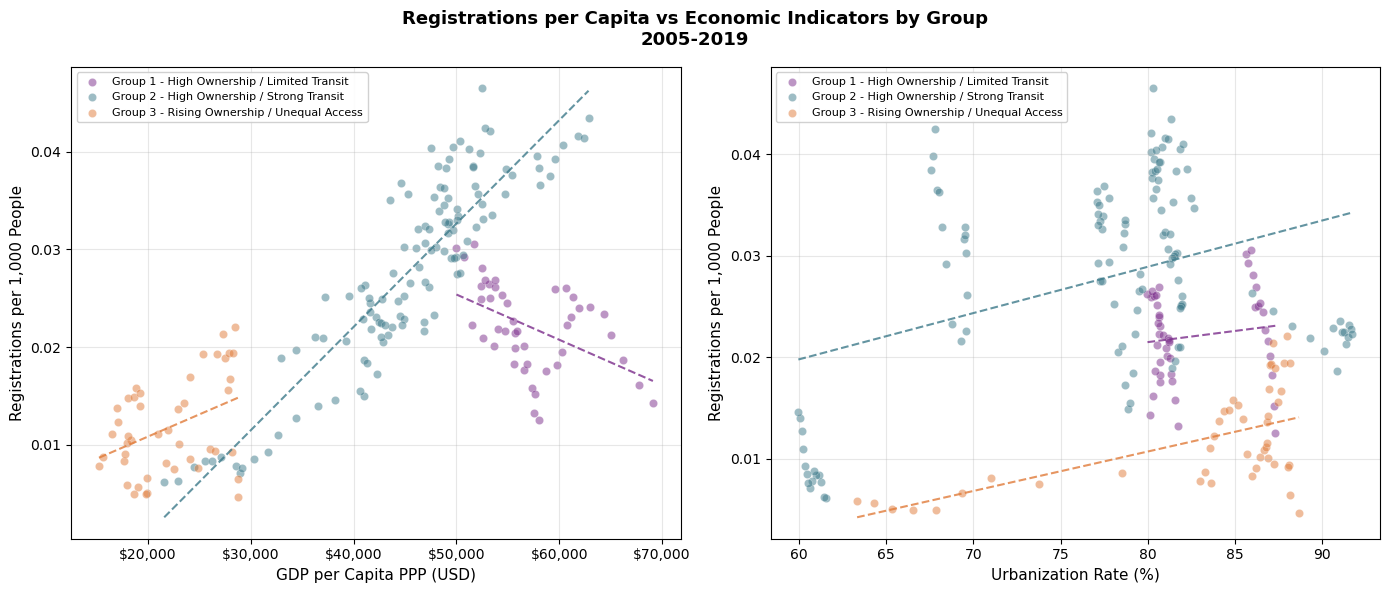

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_var, x_label in zip(
    axes,
    ['gdp_pc', 'urbanization'],
    ['GDP per Capita PPP (USD)', 'Urbanization Rate (%)']
):
    for group in [1, 2, 3]:
        subset = df_combined_ec[df_combined_ec['group'] == group]
        label  = f"Group {group} - {subset['group_label'].iloc[0]}"
        ax.scatter(subset[x_var], subset['reg_pc'],
                   color=GROUP_COLORS[group], label=label,
                   alpha=0.5, s=35, edgecolors='white', linewidth=0.3)

        z = np.polyfit(subset[x_var], subset['reg_pc'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset[x_var].min(), subset[x_var].max(), 100)
        ax.plot(x_line, p(x_line), color=GROUP_COLORS[group],
                linewidth=1.5, linestyle='--', alpha=0.8)

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel('Registrations per 1,000 People', fontsize=11)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.3)

    if x_var == 'gdp_pc':
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
        )

fig.suptitle('Registrations per Capita vs Economic Indicators by Group\n2005-2019',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 OLS Regression: Does Group Remain Significant After Controls?

Two OLS models are estimated. Model 1 uses GDP per capita and urbanization as the only predictors. Model 2 adds group dummy variables (Group 1 as reference category). Continuous predictors are standardized before estimation. The $R^2$ improvement from Model 1 to Model 2 quantifies how much additional variance group membership explains beyond economic conditions alone.

In [22]:
df_reg_ols = df_combined_ec.copy()
df_reg_ols['group2'] = (df_reg_ols['group'] == 2).astype(int)
df_reg_ols['group3'] = (df_reg_ols['group'] == 3).astype(int)

scaler = StandardScaler()
df_reg_ols[['gdp_std', 'urb_std']] = scaler.fit_transform(
    df_reg_ols[['gdp_pc', 'urbanization']]
)

# Model 1: Economic indicators only
X1 = sm.add_constant(df_reg_ols[['gdp_std', 'urb_std']])
model1 = sm.OLS(df_reg_ols['reg_pc'], X1).fit()

# Model 2: Economic indicators + group dummies
X2 = sm.add_constant(df_reg_ols[['gdp_std', 'urb_std', 'group2', 'group3']])
model2 = sm.OLS(df_reg_ols['reg_pc'], X2).fit()

def coef_rows(model):
    rows = ""
    for var, coef, pval in zip(model.params.index, model.params, model.pvalues):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        rows += f"{var:<20} coef={coef:+.5f}  p={pval:.4f} {sig}  \n"
    return rows

display(Markdown(f"""
**OLS REGRESSION RESULTS**

**Model 1: Registrations ~ GDP per Capita + Urbanization**
$R^2$: {model1.rsquared:.4f}  
Adj. $R^2$: {model1.rsquared_adj:.4f}

Coefficients:
{coef_rows(model1)}

**Model 2: Registrations ~ GDP per Capita + Urbanization + Group**
$R^2$: {model2.rsquared:.4f}  
Adj. $R^2$: {model2.rsquared_adj:.4f}

Coefficients:
{coef_rows(model2)}

$R^2$ improvement from adding group: {model2.rsquared - model1.rsquared:.4f}
"""))


**OLS REGRESSION RESULTS**

**Model 1: Registrations ~ GDP per Capita + Urbanization**
$R^2$: 0.4710  
Adj. $R^2$: 0.4659

Coefficients:
const                coef=+0.02312  p=0.0000 ***  
gdp_std              coef=+0.00694  p=0.0000 ***  
urb_std              coef=+0.00054  p=0.2983   


**Model 2: Registrations ~ GDP per Capita + Urbanization + Group**
$R^2$: 0.7441  
Adj. $R^2$: 0.7391

Coefficients:
const                coef=+0.01015  p=0.0000 ***  
gdp_std              coef=+0.01104  p=0.0000 ***  
urb_std              coef=+0.00129  p=0.0019 **  
group2               coef=+0.01599  p=0.0000 ***  
group3               coef=+0.01789  p=0.0000 ***  


$R^2$ improvement from adding group: 0.2731


### 6.6 Economic Indicator Analysis - Findings

**Overall correlations** confirm that GDP per capita is a strong predictor of registrations (Spearman r=+0.615, p<0.001). Urbanization is not significant overall (p=0.09-0.11), which is surprising given that urban populations have transit alternatives.

**Within-group correlations** reveal the most analytically interesting pattern. Group 2 (Strong Transit) shows a very strong positive relationship between GDP per capita and registrations (r=+0.883) - within European and East Asian markets, richer countries buy significantly more new passenger cars. Group 3 (Unequal Access) shows urbanization as a meaningful predictor (r=+0.533) alongside a borderline GDP effect - in Brazil, Turkey, and Chile, urban middle classes drive the market more than income level alone. Group 1 (Limited Transit) shows a significant negative correlation (r=-0.531) - within the 45 observations spanning USA, Canada, and Australia across 15 years, higher GDP values are associated with fewer passenger car registrations. This counterintuitive result warrants further investigation at the individual country level, which is outside the scope of this analysis.

**OLS regression** confirms the headline result. Adding group to an economic-only model improves $R^2$ by 0.273 - from 0.471 to 0.744. Unlike Part 3, where adding transit tier rendered economic indicators non-significant, both GDP per capita and group membership remain independently significant in Model 2. Economic conditions and group structure each explain distinct portions of registration variance in the international context. Urbanization also becomes significant (p=0.002) in Model 2, suggesting it was suppressed by omitted variable bias in Model 1.

> The group 2 coefficient (+0.016) and group 3 coefficient (+0.018) are both large and highly significant - after controlling for GDP and urbanization, both groups register more new passenger cars per capita than Group 1. This is consistent with the TOCAPA undercounting problem for Group 1 markets.

## 7. Random Forest Modeling

Section 6 established that both economic conditions and group membership independently explain registration variance. This section asks whether the momentum-dominated prediction pattern from Parts 2 and 3 holds internationally, or whether economic indicators gain predictive power in specific group types. The same feature set used in Part 3 is applied: lagged registrations (momentum), GDP per capita, urbanization, calendar year, and recession indicator.

### 7.1 Data Preparation

In [23]:
with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_reg_rf = pd.read_sql_query(
        "SELECT * FROM oecd_registrations", conn
    )
    df_gdp_rf = pd.read_sql_query(
        "SELECT * FROM wb_gdp_per_capita", conn
    ).pivot(index='year', columns='iso3', values='gdp_per_capita')
    df_pop_rf = pd.read_sql_query(
        "SELECT * FROM wb_population", conn
    ).pivot(index='year', columns='iso3', values='population')
    df_urb_rf = pd.read_sql_query(
        "SELECT * FROM wb_urbanization", conn
    ).pivot(index='year', columns='iso3', values='urbanization')
    df_meta_rf = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )

df_pop_rf_full = df_pop_rf * 1000
oecd_veh_iso3  = sorted(df_registrations_wide.columns.tolist())
df_meta_rf     = df_meta_rf[df_meta_rf['iso3'].isin(oecd_veh_iso3)].copy()

# Recession years
RECESSION_YEARS = {2008, 2009, 2020}

FEATURES = ['reg_pc_lag1', 'reg_pc_lag2', 'gdp_pc', 'urbanization', 'year', 'recession']
TARGET   = 'reg_pc'

print("Data loaded successfully")
print(f"Countries in analysis: {sorted(oecd_veh_iso3)}")

Data loaded successfully
Countries in analysis: ['AUS', 'BRA', 'CAN', 'CHL', 'DEU', 'ESP', 'FRA', 'GBR', 'ITA', 'JPN', 'KOR', 'POL', 'TUR', 'USA']


### 7.2 Feature Matrix per Country

In [24]:
def build_country_features(iso3):
    reg = df_reg_rf[df_reg_rf['iso3'] == iso3].set_index('year')['registrations']
    pop = df_pop_rf_full[iso3] if iso3 in df_pop_rf_full.columns else None

    if pop is None:
        return pd.DataFrame()

    reg_pc = (reg / pop) * 1000

    df = pd.DataFrame({
        'reg_pc':      reg_pc,
        'reg_pc_lag1': reg_pc.shift(1),
        'reg_pc_lag2': reg_pc.shift(2),
    })
    df['gdp_pc']      = df_gdp_rf[iso3].reindex(df.index) if iso3 in df_gdp_rf.columns else np.nan
    df['urbanization'] = df_urb_rf[iso3].reindex(df.index) if iso3 in df_urb_rf.columns else np.nan
    df['year']        = df.index
    df['recession']   = df.index.map(lambda y: 1 if y in RECESSION_YEARS else 0)

    return df.dropna()

country_data = {}
for iso3 in oecd_veh_iso3:
    df_c = build_country_features(iso3)
    if not df_c.empty:
        country = df_meta_rf[df_meta_rf['iso3'] == iso3]['country'].iloc[0]
        country_data[iso3] = df_c
        print(f"[OK] {country:<25} n={len(df_c)} years ({df_c.index.min()}-{df_c.index.max()})")

[OK] Australia                 n=17 years (2007-2023)
[OK] Brazil                    n=17 years (2007-2023)
[OK] Canada                    n=17 years (2007-2023)
[OK] Chile                     n=17 years (2007-2023)
[OK] Germany                   n=17 years (2007-2023)
[OK] Spain                     n=17 years (2007-2023)
[OK] France                    n=17 years (2007-2023)
[OK] United Kingdom            n=17 years (2007-2023)
[OK] Italy                     n=17 years (2007-2023)
[OK] Japan                     n=17 years (2007-2023)
[OK] South Korea               n=17 years (2007-2023)
[OK] Poland                    n=17 years (2007-2023)
[OK] Turkey                    n=17 years (2007-2023)
[OK] United States             n=17 years (2007-2023)


### 7.3 Random Forest by Group

Countries are pooled within each group to create larger training sets. Train period: 2005-2015. Test period: 2016-2019. This time-based split mirrors the approach in Parts 2 and 3 and prevents data leakage through temporal ordering.

In [25]:
TRAIN_END  = 2015
TEST_START = 2016
TEST_END   = 2019

group_results = {}

for group in [1, 2, 3]:
    group_iso3  = df_meta_rf[df_meta_rf['group'] == group]['iso3'].tolist()
    group_label = df_meta_rf[df_meta_rf['group'] == group]['group_label'].iloc[0]

    train_frames = []
    test_frames  = []

    for iso3 in group_iso3:
        if iso3 not in country_data:
            continue
        df_c = country_data[iso3]
        train_frames.append(df_c[df_c.index <= TRAIN_END])
        test_frames.append(df_c[(df_c.index >= TEST_START) & (df_c.index <= TEST_END)])

    if not train_frames:
        continue

    X_train = pd.concat(train_frames)[FEATURES]
    y_train = pd.concat(train_frames)[TARGET]
    X_test  = pd.concat(test_frames)[FEATURES]
    y_test  = pd.concat(test_frames)[TARGET]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=2,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    importance = pd.Series(rf.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False)

    group_results[group] = {
        'group_label': group_label,
        'countries':   group_iso3,
        'r2':          r2,
        'rmse':        rmse,
        'importance':  importance,
        'model':       rf
    }

    imp_rows = "".join([
        f"{feat:<15} {imp:.4f}\n"
        for feat, imp in importance.items()
    ])

    display(Markdown(f"""
**Group {group} - {group_label}**
Countries: {group_iso3}
Train: 2005-{TRAIN_END} | Test: {TEST_START}-{TEST_END}
$R^2$: {r2:.4f} | RMSE: {rmse:.6f}

Feature importance:
{imp_rows}
"""))


**Group 1 - High Ownership / Limited Transit**
Countries: ['USA', 'CAN', 'AUS']
Train: 2005-2015 | Test: 2016-2019
$R^2$: -2.6805 | RMSE: 0.004973

Feature importance:
reg_pc_lag1     0.6219
reg_pc_lag2     0.2018
year            0.0949
gdp_pc          0.0440
urbanization    0.0328
recession       0.0046




**Group 2 - High Ownership / Strong Transit**
Countries: ['DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'KOR', 'ESP', 'POL']
Train: 2005-2015 | Test: 2016-2019
$R^2$: 0.9366 | RMSE: 0.002120

Feature importance:
reg_pc_lag1     0.7638
gdp_pc          0.1413
reg_pc_lag2     0.0544
urbanization    0.0349
year            0.0051
recession       0.0005




**Group 3 - Rising Ownership / Unequal Access**
Countries: ['BRA', 'TUR', 'CHL']
Train: 2005-2015 | Test: 2016-2019
$R^2$: 0.5382 | RMSE: 0.003718

Feature importance:
reg_pc_lag1     0.5119
reg_pc_lag2     0.2605
urbanization    0.1283
gdp_pc          0.0806
year            0.0145
recession       0.0041



### 7.4 Random Forest per Country

One model per country is estimated to provide granular results. With approximately 11 training observations per country, severe overfitting is expected - this cell documents the attempt and the failure, establishing that individual country modeling is not viable with annual data at this sample size.

In [26]:
country_results = {}

for iso3 in oecd_veh_iso3:
    if iso3 not in country_data:
        continue

    df_c    = country_data[iso3]
    X_train = df_c[df_c.index <= TRAIN_END][FEATURES]
    y_train = df_c[df_c.index <= TRAIN_END][TARGET]
    X_test  = df_c[(df_c.index >= TEST_START) & (df_c.index <= TEST_END)][FEATURES]
    y_test  = df_c[(df_c.index >= TEST_START) & (df_c.index <= TEST_END)][TARGET]

    if len(X_train) < 5 or len(X_test) < 2:
        print(f"[SKIP] {iso3} - insufficient data")
        continue

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    importance = pd.Series(rf.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False)

    country = df_meta_rf[df_meta_rf['iso3'] == iso3]['country'].iloc[0]
    group   = df_meta_rf[df_meta_rf['iso3'] == iso3]['group'].iloc[0]

    country_results[iso3] = {
        'country':    country,
        'group':      group,
        'r2':         r2,
        'rmse':       rmse,
        'importance': importance
    }

    display(Markdown(f"[OK] {country:<25} Group {group}  $R^2$={r2:.4f}  RMSE={rmse:.6f}  Top: {importance.index[0]}"))

[OK] Australia                 Group 1  $R^2$=-5.1944  RMSE=0.007229  Top: year

[OK] Brazil                    Group 3  $R^2$=-9.5102  RMSE=0.003245  Top: reg_pc_lag1

[OK] Canada                    Group 1  $R^2$=-5.6525  RMSE=0.005124  Top: reg_pc_lag1

[OK] Chile                     Group 3  $R^2$=0.1345  RMSE=0.001759  Top: reg_pc_lag1

[OK] Germany                   Group 2  $R^2$=-17.9107  RMSE=0.004330  Top: reg_pc_lag1

...

[OK] Japan                     Group 2  $R^2$=-2.7486  RMSE=0.000863  Top: gdp_pc

[OK] South Korea               Group 2  $R^2$=-40.2274  RMSE=0.002394  Top: year

[OK] Poland                    Group 2  $R^2$=-11.7273  RMSE=0.005007  Top: reg_pc_lag1

[OK] Turkey                    Group 3  $R^2$=-0.2037  RMSE=0.002172  Top: urbanization

[OK] United States             Group 1  $R^2$=-4.8200  RMSE=0.006291  Top: gdp_pc

### 7.5 Time Series Cross-Validation per Country

Time series cross-validation with 3 folds is applied as a more robust evaluation than the fixed train/test split. If negative $R^2$ results were a product of the specific split rather than genuine data scarcity, cross-validation would recover positive performance.

In [27]:
tscv = TimeSeriesSplit(n_splits=3)
country_cv_results = {}

for iso3 in oecd_veh_iso3:
    if iso3 not in country_data:
        continue

    df_c = country_data[iso3]
    X    = df_c[FEATURES]
    y    = df_c[TARGET]

    fold_r2   = []
    fold_rmse = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(X_train) < 4 or len(X_test) < 2:
            continue

        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=3,
            min_samples_leaf=2,
            random_state=42
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        fold_r2.append(r2_score(y_test, y_pred))
        fold_rmse.append(mean_squared_error(y_test, y_pred) ** 0.5)

    if not fold_r2:
        continue

    mean_r2   = np.mean(fold_r2)
    mean_rmse = np.mean(fold_rmse)

    rf_full = RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    )
    rf_full.fit(X, y)
    importance = pd.Series(rf_full.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False)

    country = df_meta_rf[df_meta_rf['iso3'] == iso3]['country'].iloc[0]
    group   = df_meta_rf[df_meta_rf['iso3'] == iso3]['group'].iloc[0]

    country_cv_results[iso3] = {
        'country':    country,
        'group':      group,
        'mean_r2':    mean_r2,
        'mean_rmse':  mean_rmse,
        'importance': importance
    }

    display(Markdown(f"[OK] {country:<25} Group {group}  Mean $R^2$={mean_r2:.4f}  Mean RMSE={mean_rmse:.6f}  Top: {importance.index[0]}"))

[OK] Australia                 Group 1  Mean $R^2$=-139.0654  Mean RMSE=0.006144  Top: year

[OK] Brazil                    Group 3  Mean $R^2$=-34.9118  Mean RMSE=0.002692  Top: year

[OK] Canada                    Group 1  Mean $R^2$=-28.5335  Mean RMSE=0.005216  Top: year

[OK] Chile                     Group 3  Mean $R^2$=-0.7535  Mean RMSE=0.003206  Top: recession

[OK] Germany                   Group 2  Mean $R^2$=-16.5641  Mean RMSE=0.004850  Top: year

...

[OK] Japan                     Group 2  Mean $R^2$=-3.4066  Mean RMSE=0.001839  Top: year

[OK] South Korea               Group 2  Mean $R^2$=-14.0153  Mean RMSE=0.002493  Top: year

[OK] Poland                    Group 2  Mean $R^2$=-5.1442  Mean RMSE=0.002409  Top: urbanization

[OK] Turkey                    Group 3  Mean $R^2$=-2.2682  Mean RMSE=0.002165  Top: reg_pc_lag1

[OK] United States             Group 1  Mean $R^2$=-57.6328  Mean RMSE=0.005616  Top: urbanization

### 7.6 Feature Importance by Group

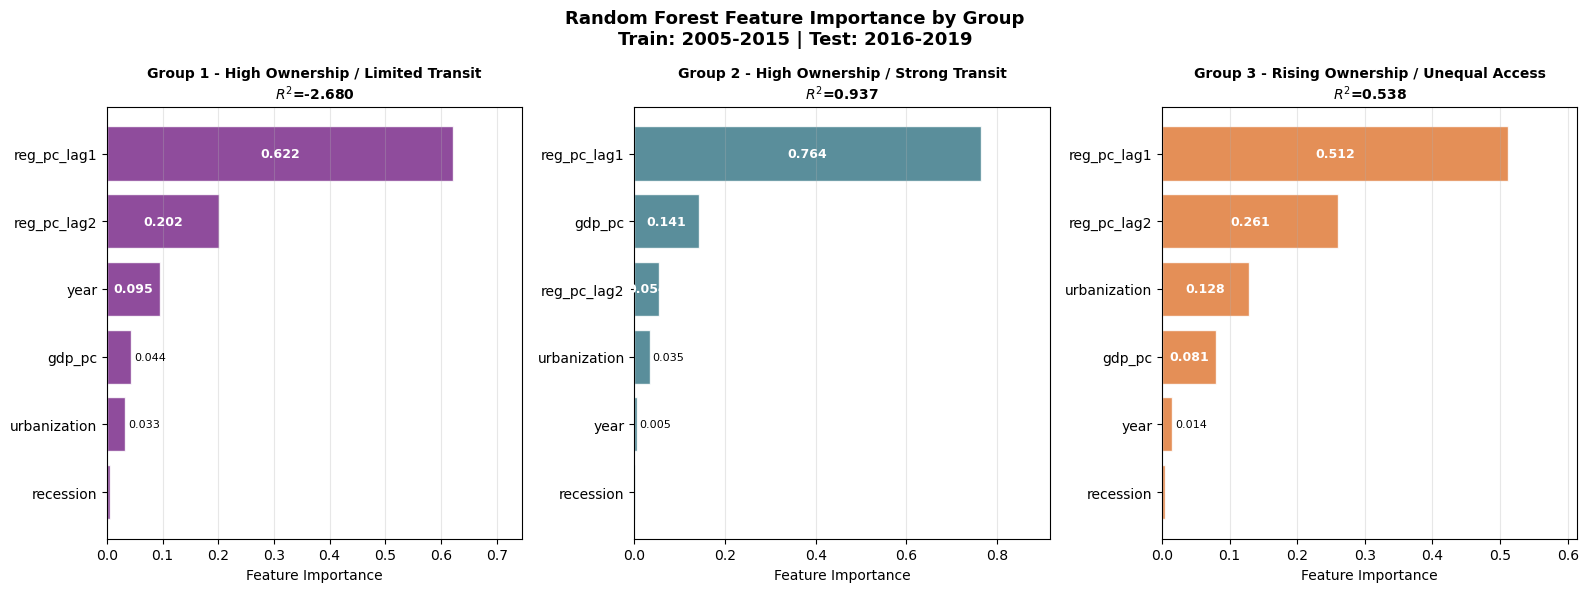

In [28]:
# 7.6 Feature Importance Visualization by Group

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (group, results) in zip(axes, group_results.items()):
    importance  = results['importance']
    group_label = results['group_label']
    r2          = results['r2']
    color       = GROUP_COLORS[group]

    bars = ax.barh(importance.index[::-1], importance.values[::-1],
                   color=color, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, importance.values[::-1]):
        if val >= 0.05:
            ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
        elif val >= 0.005:
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', ha='left', va='center',
                    fontsize=8, color='black')

    ax.set_title(f'Group {group} - {group_label}\n$R^2$={r2:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, importance.max() * 1.2)

fig.suptitle('Random Forest Feature Importance by Group\nTrain: 2005-2015 | Test: 2016-2019',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.7 Random Forest - Findings

**Group-level models** confirm the momentum dominance finding from Parts 2 and 3. Group 2 (Strong Transit) achieves $R^2$=0.937 with lag1 accounting for 76% of importance - momentum is the dominant predictor even in markets with strong transit alternatives. However, GDP per capita contributes a meaningful 14% in Group 2 - the highest economic indicator importance observed across the entire series. Group 3 (Unequal Access) achieves $R^2$=0.538 with a more balanced feature profile: lag1 (51%), lag2 (26%), urbanization (13%), GDP (8%). Group 1 (Limited Transit) fails with $R^2$=-2.68 - only 3 countries pooled with diverging patterns is insufficient for reliable modeling.

**Per-country models** yield negative $R^2$ under both fixed split and time series cross-validation for all 14 countries. 17 annual observations per country is fundamentally insufficient for Random Forest regardless of validation strategy, confirming the same finding from Part 3. The tier-level pooling approach is the appropriate unit of analysis for annual registration data.

**The key answer to the research question:** Economic conditions play a larger role in Group 2 (Strong Transit) markets than in Group 3 markets, where GDP importance (8%) is lower than urbanization (13%). In markets where car purchase is more discretionary - because transit alternatives exist - GDP per capita is a more meaningful predictor of new car registrations. This is a directional finding consistent with the central hypothesis, though the small country sample limits the strength of this conclusion.

## 8. Conclusions

### 8.1 Summary Statistics

In [29]:
UPT_LABELS = {
    1: 'Limited transit infrastructure outside major cities',
    2: 'Extensive rail and urban transit networks',
    3: 'Growing transit in megacities, limited elsewhere',
}

with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_meta_conc = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )

df_meta_conc = df_meta_conc[df_meta_conc['iso3'].isin(oecd_veh_iso3)].copy()

summary_records = []
for group in [1, 2, 3]:
    group_iso3  = df_meta_conc[df_meta_conc['group'] == group]['iso3'].tolist()
    group_label = df_meta_conc[df_meta_conc['group'] == group]['group_label'].iloc[0]
    countries   = df_meta_conc[df_meta_conc['group'] == group]['country'].tolist()

    group_data = df_combined_ec[df_combined_ec['group'] == group]

    reg_median  = group_data['reg_pc'].median()
    gdp_median  = group_data['gdp_pc'].median()
    urb_median  = group_data['urbanization'].median()
    rf_r2       = group_results[group]['r2']
    top_feature = group_results[group]['importance'].index[0]

    summary_records.append({
        'Group':               f'Group {group} - {group_label}',
        'Countries':           ', '.join(countries),
        'Reg/1000 (median)':   f'{reg_median:.4f}',
        'GDP/capita (median)': f'${gdp_median:,.0f}',
        'Urban % (median)':    f'{urb_median:.1f}%',
        'RF $R^2$':            f'{rf_r2:.3f}',
        'Top RF Feature':       top_feature,
    })

df_summary_conc = pd.DataFrame(summary_records).set_index('Group')

display(Markdown("**PART 4 SUMMARY - GLOBAL AUTO SALES ANALYSIS**"))
display(df_summary_conc)

**PART 4 SUMMARY - GLOBAL AUTO SALES ANALYSIS**

,Countries,Reg/1000 (median),GDP/capita (median),Urban % (median),RF $R^2$,Top RF Feature
Group,,,,,,
Group 1 - High Ownership / Limited Transit,"United States, Canada, Australia",0.0222,"$55,880",81.2%,-2.680,reg_pc_lag1
Group 2 - High Ownership / Strong Transit,"Germany, France, United Kingdom, Italy, Japan,...",0.0292,"$46,907",79.9%,0.937,reg_pc_lag1
Group 3 - Rising Ownership / Unequal Access,"Brazil, Turkey, Chile",0.0109,"$21,760",86.2%,0.538,reg_pc_lag1


### 8.2 Key Findings

**Main hypothesis - REJECT H0.** Groups differ significantly in per-capita registration rates (Kruskal-Wallis H=82.19, p<0.001, $\eta^2$=0.39, large effect). All three pairwise comparisons are significant after Bonferroni correction. The group structure reflects genuinely distinct market types.

**The counterintuitive finding.** Group 2 (Strong Transit) has higher median new car registrations per capita than Group 1 (Limited Transit). This reflects the TOCAPA data limitation - passenger cars only, excluding trucks and SUVs that dominate Group 1 markets. This caveat applies to all registration-level comparisons in this analysis.

**Recession sensitivity - FAIL TO REJECT H0** for both 2008-2009 (p=0.26) and 2020 COVID (p=0.24). Tests are severely underpowered with n=3 countries per group. The COVID result is substantively interesting regardless of statistical significance: all groups declined uniformly (-31%, -24%, -29%), suggesting the pandemic was a universal demand shock that overrode structural market differences.

**OLS regression.** Adding group membership improves $R^2$ by 0.273 (from 0.471 to 0.744). Unlike Part 3, both GDP per capita and group remain independently significant after controlling for each other - economic conditions and group structure each explain distinct portions of registration variance in the international context.

**Random Forest by group.** Group 2 achieves $R^2$=0.937 with GDP contributing 14% importance - the highest economic indicator contribution observed across the series. Group 3 is more balanced with urbanization (13%) outweighing GDP (8%). Group 1 fails due to sample size. The finding is directionally consistent with the hypothesis: economic conditions matter more in transit-rich markets where car purchase is discretionary.

### 8.3 Limitations

The OECD TOCAPA indicator covers new passenger car registrations only. Trucks, SUVs, vans, and used vehicle purchases are excluded, systematically undercounting Group 1 markets and making cross-group level comparison of registration rates unreliable.

Lower-income country groups were excluded due to absence of reliable machine-readable time series data. OICA direct downloads are no longer publicly accessible following a website redesign. World Bank vehicle ownership indicators were removed in 2015 due to an IRF licensing dispute. The research question cannot be meaningfully addressed for these markets with available free data.

Group 1 contains only 3 countries - too few for reliable pooled modeling or hypothesis testing. Results for this group should be interpreted with caution throughout.

Annual data frequency limits modeling sophistication. Monthly data would enable ARIMA and more reliable per-country Random Forest with sufficient observations.

### 8.4 Future Work

Sourcing total vehicle sales data including trucks, SUVs, and used vehicles for Group 1 markets would resolve the primary data limitation and enable genuine cross-group registration comparison.

Part 5 will examine the EV transition - how electrification is reshaping demand patterns across markets, with particular focus on the divergence between Group 2 markets where EV adoption has been fastest and Group 1 markets where it has lagged despite high income levels.

## 9. Interactive Dashboard

### 9.1 Dashboard Data Preparation

All data for the dashboard is loaded from `auto_sales_global.sqlite`. Feature importance values are hardcoded from the Section 7 group-level models to avoid retraining Random Forest models inside the dashboard cell, ensuring the cell is self-contained and can be rerun independently.

In [30]:
with sqlite3.connect('auto_sales_global.sqlite') as conn:
    df_dash_reg = pd.read_sql_query(
        "SELECT * FROM oecd_registrations", conn
    )
    df_dash_gdp = pd.read_sql_query(
        "SELECT * FROM wb_gdp_per_capita", conn
    ).pivot(index='year', columns='iso3', values='gdp_per_capita')
    df_dash_pop = pd.read_sql_query(
        "SELECT * FROM wb_population", conn
    ).pivot(index='year', columns='iso3', values='population')
    df_dash_urb = pd.read_sql_query(
        "SELECT * FROM wb_urbanization", conn
    ).pivot(index='year', columns='iso3', values='urbanization')
    df_dash_meta = pd.read_sql_query(
        "SELECT * FROM country_metadata", conn
    )
    df_dash_who = pd.read_sql_query(
        "SELECT * FROM who_death_rate", conn
    )

df_dash_meta = df_dash_meta[df_dash_meta['iso3'].isin(oecd_veh_iso3)].copy()
df_dash_pop_full = df_dash_pop * 1000

# Build long format registration DataFrame with per capita
dash_records = []
for _, meta_row in df_dash_meta.iterrows():
    iso3        = meta_row['iso3']
    country     = meta_row['country']
    group       = meta_row['group']
    group_label = meta_row['group_label']

    reg_series = df_dash_reg[df_dash_reg['iso3'] == iso3].set_index('year')['registrations']

    for year in reg_series.index:
        reg = reg_series.loc[year]
        pop = df_dash_pop_full.loc[year, iso3] if iso3 in df_dash_pop_full.columns else np.nan
        gdp = df_dash_gdp.loc[year, iso3] if iso3 in df_dash_gdp.columns and year in df_dash_gdp.index else np.nan
        urb = df_dash_urb.loc[year, iso3] if iso3 in df_dash_urb.columns and year in df_dash_urb.index else np.nan

        dash_records.append({
            'year':        year,
            'iso3':        iso3,
            'country':     country,
            'group':       group,
            'group_label': group_label,
            'registrations': reg,
            'reg_pc':      (reg / pop) * 1000 if not np.isnan(pop) and pop > 0 else np.nan,
            'gdp_pc':      gdp,
            'urbanization': urb,
        })

df_dash_plot = pd.DataFrame(dash_records)

# WHO death rate lookup
who_dict = df_dash_who.set_index('iso3')['death_rate_2021'].to_dict()

# Recession sensitivity from Section 4
df_recession_dash = df_recession_eda.copy()

# Feature importance hardcoded from Section 7
GROUP_IMPORTANCE = {
    1: {
        'label': 'High Ownership / Limited Transit',
        'r2': -2.680,
        'importance': pd.Series({
            'reg_pc_lag1':   0.6219,
            'reg_pc_lag2':   0.2018,
            'year':          0.0949,
            'gdp_pc':        0.0440,
            'urbanization':  0.0328,
            'recession':     0.0046,
        }).sort_values(ascending=False)
    },
    2: {
        'label': 'High Ownership / Strong Transit',
        'r2': 0.937,
        'importance': pd.Series({
            'reg_pc_lag1':   0.7638,
            'gdp_pc':        0.1413,
            'reg_pc_lag2':   0.0544,
            'urbanization':  0.0349,
            'year':          0.0051,
            'recession':     0.0005,
        }).sort_values(ascending=False)
    },
    3: {
        'label': 'Rising Ownership / Unequal Access',
        'r2': 0.538,
        'importance': pd.Series({
            'reg_pc_lag1':   0.5119,
            'reg_pc_lag2':   0.2605,
            'urbanization':  0.1283,
            'gdp_pc':        0.0806,
            'year':          0.0145,
            'recession':     0.0041,
        }).sort_values(ascending=False)
    },
}

RECESSION_BANDS = [
    {'x0': 2007.5, 'x1': 2009.5},
    {'x0': 2019.5, 'x1': 2020.5},
]

COUNTRY_DASH_STYLES = {
    'United States':  'solid',
    'Canada':         'dash',
    'Australia':      'dot',
    'Germany':        'solid',
    'France':         'dash',
    'United Kingdom': 'dot',
    'Italy':          'dashdot',
    'Japan':          'solid',
    'Poland':         'dash',
    'South Korea':    'dot',
    'Spain':          'dashdot',
    'Brazil':         'solid',
    'Chile':          'dash',
    'Turkey':         'dot',
}

print("Dashboard data prepared")
print(f"  Registration records: {len(df_dash_plot)}")
print(f"  Countries: {df_dash_meta['country'].tolist()}")

Dashboard data prepared
  Registration records: 266
  Countries: ['United States', 'Canada', 'Australia', 'Germany', 'France', 'United Kingdom', 'Italy', 'Japan', 'South Korea', 'Spain', 'Poland', 'Brazil', 'Turkey', 'Chile']


### 9.2 Plotly Choropleth World Map

In [31]:
# Build GeoJSON color mapping
group_map = df_dash_meta.set_index('iso3')['group'].to_dict()

# Use plotly choropleth instead of folium for country-level coloring
fig_map = go.Figure(data=go.Choropleth(
    locations=df_dash_meta['iso3'],
    z=df_dash_meta['group'].astype(float),
    colorscale=[
        [0.0,   '#7B2D8B'],
        [0.5,   '#3D7A8A'],
        [1.0,   '#E07B39'],
    ],
    zmin=1, zmax=3,
    showscale=False,
    text=df_dash_meta['country'],
    customdata=df_dash_meta[['group', 'group_label']],
    hovertemplate='<b>%{text}</b><br>Group %{customdata[0]} - %{customdata[1]}<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5,
))

fig_map.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#f8f9fa',
        showland=True,
        landcolor='#e8e8e8',
        showocean=True,
        oceancolor='#d4e8f0',
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    paper_bgcolor='#f8f9fa',
)

# Add legend annotation
fig_map.add_annotation(
    x=0.01, y=0.15, xref='paper', yref='paper',
    text=(
        '<b>Groups</b><br>'
        '<span style="color:#7B2D8B">&#9632;</span> Group 1 - Limited Transit<br>'
        '<span style="color:#3D7A8A">&#9632;</span> Group 2 - Strong Transit<br>'
        '<span style="color:#E07B39">&#9632;</span> Group 3 - Unequal Access'
    ),
    showarrow=False,
    align='left',
    bgcolor='white',
    bordercolor='#ccc',
    borderwidth=1,
    font=dict(size=11)
)

print("Map created successfully")

Map created successfully


### 9.3 Dash Application

The dashboard runs at http://127.0.0.1:8050. Six tabs present the key findings interactively: a Plotly choropleth world map with countries colored by group, per-capita registration trends with group and country filters, economic indicator time series, a GDP versus registrations scatter plot, recession sensitivity by recession period, and Random Forest feature importance by group.

In [32]:
app = Dash(__name__)

COUNTRIES_LIST = sorted(df_dash_meta['country'].tolist())
GROUPS_LIST = [
    {'label': 'All Groups', 'value': 0},
    {'label': 'Group 1 - High Ownership / Limited Transit',    'value': 1},
    {'label': 'Group 2 - High Ownership / Strong Transit',     'value': 2},
    {'label': 'Group 3 - Rising Ownership / Unequal Access',   'value': 3},
]

app.layout = html.Div([

    # Header
    html.Div([
        html.H2("Global Auto Sales Analysis",
                style={'margin': '0', 'color': '#2E4057'}),
        html.P("Passenger Car Registrations Across Market Groups | 2005-2023",
               style={'margin': '4px 0 0 0', 'color': '#666', 'fontSize': '13px'}),
    ], style={'padding': '16px 24px', 'borderBottom': '2px solid #eee',
              'backgroundColor': 'white'}),

    # Tabs
    dcc.Tabs(id='tabs', value='tab-map', children=[

        # Tab 1: World Map
        dcc.Tab(label='World Map', value='tab-map', children=[
            dcc.Graph(
                figure=fig_map,
                style={'height': '580px'},
                config={'scrollZoom': True}
            )
        ]),

        # Tab 2: Registrations
        dcc.Tab(label='Registrations', value='tab-reg', children=[
            html.Div([
                html.Div([
                    html.Label('Filter by Group:', style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='group-filter',
                        options=GROUPS_LIST,
                        value=0,
                        clearable=False,
                        style={'width': '320px'}
                    ),
                ], style={'display': 'inline-block', 'marginRight': '24px'}),
                html.Div([
                    html.Label('Select Countries:', style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='country-filter',
                        options=[{'label': c, 'value': c} for c in COUNTRIES_LIST],
                        value=COUNTRIES_LIST,
                        multi=True,
                        style={'width': '500px'}
                    ),
                ], style={'display': 'inline-block'}),
            ], style={'padding': '16px 24px 0 24px'}),
            dcc.Graph(id='reg-chart', style={'height': '520px'})
        ]),

        # Tab 3: Economic Indicators
        dcc.Tab(label='Economic Indicators', value='tab-econ', children=[
            html.Div([
                html.Label('Indicator:', style={'fontWeight': 'bold'}),
                dcc.RadioItems(
                    id='indicator-select',
                    options=[
                        {'label': '  GDP per Capita', 'value': 'gdp_pc'},
                        {'label': '  Urbanization Rate', 'value': 'urbanization'},
                    ],
                    value='gdp_pc',
                    inline=True,
                    style={'marginTop': '8px'}
                ),
            ], style={'padding': '16px 24px 0 24px'}),
            dcc.Graph(id='econ-chart', style={'height': '520px'})
        ]),

        # Tab 4: GDP vs Registrations Scatter
        dcc.Tab(label='GDP vs Registrations', value='tab-scatter', children=[
            dcc.Graph(id='scatter-chart', style={'height': '560px'})
        ]),

        # Tab 5: Recession Sensitivity
        dcc.Tab(label='Recession Sensitivity', value='tab-rec', children=[
            html.Div([
                html.Label('Recession:', style={'fontWeight': 'bold'}),
                dcc.RadioItems(
                    id='recession-select',
                    options=[
                        {'label': '  2008-2009 Financial Crisis',
                         'value': '2008-2009 Financial Crisis'},
                        {'label': '  2020 COVID',
                         'value': '2020 COVID'},
                    ],
                    value='2008-2009 Financial Crisis',
                    inline=True,
                    style={'marginTop': '8px'}
                ),
            ], style={'padding': '16px 24px 0 24px'}),
            dcc.Graph(id='rec-chart', style={'height': '520px'})
        ]),

        # Tab 6: Random Forest
        dcc.Tab(label='Random Forest', value='tab-rf', children=[
            dcc.Graph(id='rf-chart', style={'height': '520px'})
        ]),

    ], style={'margin': '16px 24px'}),

], style={'fontFamily': 'Arial', 'backgroundColor': '#f8f9fa', 'minHeight': '100vh'})


# Callbacks

@app.callback(
    Output('reg-chart', 'figure'),
    Input('group-filter', 'value'),
    Input('country-filter', 'value')
)
def update_reg_chart(group_filter, selected_countries):
    df = df_dash_plot.copy()
    if group_filter != 0:
        df = df[df['group'] == group_filter]
    if selected_countries:
        df = df[df['country'].isin(selected_countries)]

    fig = go.Figure()

    for band in RECESSION_BANDS:
        fig.add_vrect(x0=band['x0'], x1=band['x1'],
                      fillcolor='grey', opacity=0.12,
                      layer='below', line_width=0,
                      annotation_text='Recession',
                      annotation_position='top left',
                      annotation_font_size=10)

    for country in df['country'].unique():
        cdf   = df[df['country'] == country].sort_values('year')
        group = cdf['group'].iloc[0]
        fig.add_trace(go.Scatter(
            x=cdf['year'], y=cdf['reg_pc'],
            name=country,
            mode='lines+markers',
            line=dict(
                color=GROUP_COLORS[group],
                dash=COUNTRY_DASH_STYLES.get(country, 'solid'),
                width=2
            ),
            marker=dict(size=5)
        ))

    fig.update_layout(
        title='New Passenger Car Registrations per 1,000 People',
        xaxis_title='Year',
        yaxis_title='Registrations per 1,000 people',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=180)
    )
    return fig


@app.callback(
    Output('econ-chart', 'figure'),
    Input('indicator-select', 'value')
)
def update_econ_chart(indicator):
    fig = go.Figure()

    for band in RECESSION_BANDS:
        fig.add_vrect(x0=band['x0'], x1=band['x1'],
                      fillcolor='grey', opacity=0.12,
                      layer='below', line_width=0)

    y_label = 'GDP per Capita PPP (USD)' if indicator == 'gdp_pc' else 'Urbanization Rate (%)'
    title   = 'GDP per Capita by Country and Group' if indicator == 'gdp_pc' \
              else 'Urbanization Rate by Country and Group'

    for _, meta_row in df_dash_meta.iterrows():
        country = meta_row['country']
        iso3    = meta_row['iso3']
        group   = meta_row['group']

        subset = df_dash_plot[df_dash_plot['country'] == country].sort_values('year')
        if subset.empty:
            continue

        fig.add_trace(go.Scatter(
            x=subset['year'],
            y=subset[indicator],
            name=country,
            mode='lines+markers',
            line=dict(
                color=GROUP_COLORS[group],
                dash=COUNTRY_DASH_STYLES.get(country, 'solid'),
                width=2
            ),
            marker=dict(size=4)
        ))

    yaxis = dict(title=y_label)
    if indicator == 'gdp_pc':
        yaxis['tickformat'] = '$,.0f'

    fig.update_layout(
        title=title,
        xaxis_title='Year',
        yaxis=yaxis,
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=180)
    )
    return fig


@app.callback(
    Output('scatter-chart', 'figure'),
    Input('tabs', 'value')
)
def update_scatter_chart(tab):
    fig = go.Figure()

    for group in [1, 2, 3]:
        subset = df_dash_plot[df_dash_plot['group'] == group].dropna(
            subset=['gdp_pc', 'reg_pc']
        )
        label = GROUP_IMPORTANCE[group]['label']
        fig.add_trace(go.Scatter(
            x=subset['gdp_pc'],
            y=subset['reg_pc'],
            mode='markers',
            name=f'Group {group} - {label}',
            marker=dict(
                color=GROUP_COLORS[group],
                size=6,
                opacity=0.6
            ),
            text=subset['country'],
            hovertemplate='%{text}<br>GDP: $%{x:,.0f}<br>Reg/1000: %{y:.4f}<extra></extra>'
        ))

    fig.update_layout(
        title='GDP per Capita vs New Registrations per 1,000 People<br>2005-2023',
        xaxis_title='GDP per Capita PPP (USD)',
        yaxis_title='Registrations per 1,000 people',
        xaxis_tickformat='$,.0f',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=220)
    )
    return fig


@app.callback(
    Output('rec-chart', 'figure'),
    Input('recession-select', 'value')
)
def update_rec_chart(recession_name):
    subset = df_recession_dash[
        df_recession_dash['recession'] == recession_name
    ].sort_values('group')

    if subset.empty:
        return go.Figure()

    colors = [GROUP_COLORS[g] for g in subset['group']]

    fig = go.Figure(go.Bar(
        x=subset['country'],
        y=subset['pct_change'],
        marker_color=colors,
        opacity=0.85,
        text=[f'{v:.1f}%' for v in subset['pct_change']],
        textposition='inside',
        textfont=dict(color='white', size=11)
    ))

    fig.add_hline(y=0, line_color='black', line_width=1)

    fig.update_layout(
        title=f'Recession Sensitivity: % Change in Registrations per Capita<br>{recession_name}',
        xaxis_title='Country',
        yaxis_title='% Change',
        yaxis_tickformat='.1f',
        plot_bgcolor='white',
        paper_bgcolor='white',
    )
    return fig


@app.callback(
    Output('rf-chart', 'figure'),
    Input('tabs', 'value')
)
def update_rf_chart(tab):
    fig = go.Figure()

    for group, results in GROUP_IMPORTANCE.items():
        importance = results['importance']
        label      = results['label']
        r2         = results['r2']
        color      = GROUP_COLORS[group]

        fig.add_trace(go.Bar(
            name=f'Group {group} - {label} (R2={r2:.3f})',
            x=importance.index.tolist(),
            y=importance.values.tolist(),
            marker_color=color,
            opacity=0.85,
        ))

    fig.update_layout(
        title='Random Forest Feature Importance by Group<br>Train: 2005-2015 | Test: 2016-2019',
        xaxis_title='Feature',
        yaxis_title='Importance',
        barmode='group',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=280)
    )
    return fig


if __name__ == '__main__':
    app.run(debug=True, port=8051)